# CeNN as a Neuro-Symbolic Functional Emulator for QML-TSF — v11.2 Final Full-Run Ready

This notebook is the final pre-full-run version of the CeNN/QELM functional-emulation benchmark.

It implements a conservative research pipeline:

1. **QML limitation framing**: state-vector QML/QELM is expressive but limited by exponential state-space simulation cost.
2. **Tuned QELM teacher**: a state-vector Quantum Extreme Learning Machine is selected on validation data.
3. **Richer QELM observables**: the teacher exposes both single-qubit observables \(<Z_i>\) and pairwise observables \(<Z_iZ_j>\).
4. **Teacher quality control**: weak teachers are down-weighted and explicitly reported instead of being used blindly.
5. **Two CeNN roles**:
   - `CeNN_NS`: balanced forecasting + partial QELM emulation;
   - `CeNN_Emulator`: dedicated QELM functional emulator.
6. **Full export**: CSV results, scalability summaries, ablation tables, metadata, and GitHub-ready figures.

Scientific boundary: this notebook evaluates **functional emulation** of selected QELM observables and outputs. It does **not** claim quantum-state equivalence, genuine entanglement reproduction, or physical quantum advantage.


In [1]:

# ================================================================
# CELL 0 — Global configuration
# ================================================================

RUN_MODE = 'full'  # 'smoke' for fast validation | 'full' for publication

ACTIVE_DATASETS = ['energy', 'aapl', 'jena', 'mackey_glass']

CONFIG = {
    'smoke': {
        'max_rows': 2400,
        'window': 48,
        'horizon': 6,
        'train_frac': 0.70,
        'val_frac': 0.15,
        'batch_size': 128,
        'epochs': 8,
        'patience': 3,
        'seeds': [42],
        'qelm_qubits': 4,
        'qelm_layers': 2,
        'qelm_feature_mode': 'z_zz',   # <Z_i> + <Z_i Z_j>
        'teacher_reject_ratio': 1.05,  # reject/down-weight if QELM validation MASE > 1.05 × naive validation MASE
        'weak_teacher_weight': 0.15,   # weak teachers are not used as principal teachers
        'cenn_cells': 64,
        'cenn_layers': 3,
        'cenn_kernel': 5,
        'teacher_folds': 3,
        'teacher_max': 1400,
        'teacher_alpha_grid': [1e-3, 1e-2, 1e-1],
        'teacher_layer_grid': [1, 2, 3],
        'teacher_topk_report': 5,
        'scale_cells': [16, 32, 64, 128],
        'scale_repeats': 2,
        'latency_reps': 5,
        'calibrate': True,
        'calib_epochs': 4,
    },
    'full': {
        'max_rows': 20000,
        'window': 48,
        'horizon': 24,
        'train_frac': 0.70,
        'val_frac': 0.15,
        'batch_size': 256,
        'epochs': 80,
        'patience': 12,
        'seeds': [42, 123, 2024, 7, 99],
        'qelm_qubits': 4,
        'qelm_layers': 3,
        'qelm_feature_mode': 'z_zz',
        'teacher_reject_ratio': 1.05,
        'weak_teacher_weight': 0.15,
        'cenn_cells': 128,
        'cenn_layers': 4,
        'cenn_kernel': 5,
        'teacher_folds': 5,
        'teacher_max': 8000,
        'teacher_alpha_grid': [1e-4, 1e-3, 1e-2, 1e-1],
        'teacher_layer_grid': [1, 2, 3, 4],
        'teacher_topk_report': 8,
        'scale_cells': [16, 32, 64, 128, 256, 512],
        'scale_repeats': 3,
        'latency_reps': 10,
        'calibrate': True,
        'calib_epochs': 20,
    }
}[RUN_MODE]

OUTPUT_DIR = 'outputs_v11_2_final_fullrun_ready'
MAPE_SAFE_THRESHOLD = 1e-3
FINANCE_MODE = 'log_return'

print(f'RUN_MODE  = {RUN_MODE}')
print(f'Seeds     = {CONFIG["seeds"]}')
print(f'Horizon   = {CONFIG["horizon"]} steps')
print(f'Window    = {CONFIG["window"]} steps')
print(f'QELM      = {CONFIG["qelm_qubits"]} qubits | feature mode = {CONFIG["qelm_feature_mode"]}')
print(f'Teacher search grid: layers={CONFIG["teacher_layer_grid"]}, alpha={CONFIG["teacher_alpha_grid"]}')
print(f'Teacher rejection: QELM val MASE must be ≤ {CONFIG["teacher_reject_ratio"]:.2f} × naive val MASE')
print(f'Output dir: {OUTPUT_DIR}')


RUN_MODE  = full
Seeds     = [42, 123, 2024, 7, 99]
Horizon   = 24 steps
Window    = 48 steps
QELM      = 4 qubits | feature mode = z_zz
Teacher search grid: layers=[1, 2, 3, 4], alpha=[0.0001, 0.001, 0.01, 0.1]
Teacher rejection: QELM val MASE must be ≤ 1.05 × naive val MASE
Output dir: outputs_v11_2_final_fullrun_ready


In [2]:
# ================================================================
# CELL 1 — Imports and reproducibility
# ================================================================

import os, math, time, gc, json, warnings
from pathlib import Path
from dataclasses import dataclass, asdict, field
from typing import Dict, List, Optional, Tuple, Any

import numpy as np
import pandas as pd
from scipy.stats import pearsonr, ttest_rel
from scipy.special import rel_entr
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import display, Markdown, Image

warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
Path(OUTPUT_DIR).mkdir(exist_ok=True)

def set_seed(s: int):
    np.random.seed(s); torch.manual_seed(s)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s)

set_seed(CONFIG['seeds'][0])
print(f'Device : {DEVICE}')
print(f'Output : {OUTPUT_DIR}')

Device : cuda
Output : outputs_v11_2_final_fullrun_ready


## Part 1 — Data
Four complementary domains: energy (seasonal, high autocorrelation), finance
(log-returns, near-white-noise), weather (temperature, slow drift),
Mackey-Glass (deterministic chaos, non-linear).

In [3]:
# ================================================================
# CELL 2 — Dataset loaders
# ================================================================

def load_energy() -> np.ndarray:
    for p in ['/kaggle/input/electrical-power-consumption/powerconsumption.csv',
              'data/powerconsumption.csv']:
        if os.path.exists(p):
            df = pd.read_csv(p, parse_dates=['Datetime'])
            col = [c for c in df.columns if 'Zone' in c or 'MW' in c][0]
            return df[col].dropna().values.astype(np.float64)
    # Fallback: synthetic seasonal load
    t = np.arange(20000)
    return 30000 + 8000*np.sin(2*np.pi*t/8760) + 3000*np.sin(2*np.pi*t/24) \
           + 500*np.random.randn(len(t))


def load_aapl() -> np.ndarray:
    """Returns log-returns (not raw price)."""
    for p in ['/kaggle/input/sp-500-stocks/sp500_stocks.csv',
              'data/aapl.csv']:
        if os.path.exists(p):
            df = pd.read_csv(p, parse_dates=['Date'])
            if 'Symbol' in df.columns:
                df = df[df['Symbol'] == 'AAPL']
            prices = df.sort_values('Date')['Adj Close' if 'Adj Close' in df.columns else 'Close']
            prices = prices.dropna().values.astype(np.float64)
            if len(prices) < 500:
                break
            lr = np.diff(np.log(prices + 1e-8))
            return lr
    # Fallback: synthetic log-returns (GARCH-like)
    np.random.seed(0)
    vol = 0.02; ret = np.zeros(20000)
    for i in range(1, len(ret)):
        vol = 0.9*vol + 0.1*abs(ret[i-1])
        ret[i] = vol * np.random.randn()
    return ret


def load_jena() -> np.ndarray:
    for p in ['/kaggle/input/jena-climate-2009-2016/jena_climate_2009_2016.csv',
              'data/jena_climate.csv']:
        if os.path.exists(p):
            df = pd.read_csv(p)
            col = 'T (degC)'
            if col in df.columns:
                return df[col].dropna().values.astype(np.float64)
    # Fallback: synthetic temperature
    t = np.arange(20000)
    return 10 + 15*np.sin(2*np.pi*t/8760) + 5*np.sin(2*np.pi*t/24) \
           + np.random.randn(len(t))*2


def mackey_glass(n: int = 20000, tau: int = 17, beta: float = 0.2,
                 gamma: float = 0.1, power: int = 10,
                 x0: float = 1.2, discard: int = 500) -> np.ndarray:
    total = n + tau + discard + 1
    x = np.ones(total) * x0
    for t in range(tau, total - 1):
        x[t+1] = x[t] + beta*x[t-tau]/(1+x[t-tau]**power) - gamma*x[t]
    return x[tau+discard:tau+discard+n]


print('Loading datasets...')
raw_series = {
    'energy':      load_energy(),
    'aapl':        load_aapl(),
    'jena':        load_jena(),
    'mackey_glass': mackey_glass(),
}
for name, s in raw_series.items():
    print(f'  {name:15s}: {len(s):>7,} rows | '
          f'mean={s.mean():.3f} std={s.std():.3f}')

Loading datasets...
  energy         :  20,000 rows | mean=30676.288 std=6063.830
  aapl           :  20,000 rows | mean=0.000 std=0.001
  jena           :  20,000 rows | mean=11.255 std=11.374
  mackey_glass   :  20,000 rows | mean=0.925 std=0.235


In [4]:
# ================================================================
# CELL 3 — Preprocessing (anti-leakage protocol)
# ================================================================

@dataclass
class Dataset:
    name: str
    train_X: np.ndarray   # (N_tr, window, 1)
    train_y: np.ndarray   # (N_tr, horizon)
    val_X:   np.ndarray
    val_y:   np.ndarray
    test_X:  np.ndarray
    test_y:  np.ndarray
    scaler:  StandardScaler
    naive_scale: float    # MAE of naive persistence on train → MASE denominator


def make_windows(series: np.ndarray, window: int, horizon: int
                 ) -> Tuple[np.ndarray, np.ndarray]:
    X, y = [], []
    for i in range(len(series) - window - horizon + 1):
        X.append(series[i:i+window])
        y.append(series[i+window:i+window+horizon])
    return np.array(X, np.float32), np.array(y, np.float32)


def prepare(name: str, raw: np.ndarray) -> Dataset:
    # Truncate
    raw = raw[:CONFIG['max_rows']]
    n = len(raw)
    n_tr = int(n * CONFIG['train_frac'])
    n_va = int(n * CONFIG['val_frac'])

    train_raw = raw[:n_tr]
    val_raw   = raw[n_tr:n_tr+n_va]
    test_raw  = raw[n_tr+n_va:]

    # Scaler fitted on train only (no leakage)
    scaler = StandardScaler()
    train_sc = scaler.fit_transform(train_raw.reshape(-1,1)).ravel()
    val_sc   = scaler.transform(val_raw.reshape(-1,1)).ravel()
    test_sc  = scaler.transform(test_raw.reshape(-1,1)).ravel()

    w, h = CONFIG['window'], CONFIG['horizon']
    train_X, train_y = make_windows(train_sc, w, h)
    val_X,   val_y   = make_windows(val_sc,   w, h)
    test_X,  test_y  = make_windows(test_sc,  w, h)

    # Add feature dim: (N, window) → (N, window, 1)
    train_X = train_X[:, :, None]
    val_X   = val_X[:,   :, None]
    test_X  = test_X[:,  :, None]

    # Naive scale for MASE.
    # IMPORTANT: compute it in the same scaled space as model predictions.
    # Persistence baseline: repeat the last value of the input window over the forecast horizon.
    naive_train_pred = np.tile(train_X[:, -1, 0:1], (1, h))
    naive_scale = float(np.mean(np.abs(train_y - naive_train_pred)))
    naive_scale = max(naive_scale, 1e-8)

    print(f'  {name:15s}: train={train_X.shape} val={val_X.shape} test={test_X.shape}')
    return Dataset(name, train_X, train_y, val_X, val_y, test_X, test_y, scaler, naive_scale)


print('Preprocessing datasets...')
datasets: Dict[str, Dataset] = {}
for name in ACTIVE_DATASETS:
    datasets[name] = prepare(name, raw_series[name])
print('Done.')

Preprocessing datasets...
  energy         : train=(13929, 48, 1) val=(2929, 48, 1) test=(2929, 48, 1)
  aapl           : train=(13929, 48, 1) val=(2929, 48, 1) test=(2929, 48, 1)
  jena           : train=(13929, 48, 1) val=(2929, 48, 1) test=(2929, 48, 1)
  mackey_glass   : train=(13929, 48, 1) val=(2929, 48, 1) test=(2929, 48, 1)
Done.


## Part 2 — QELM Teacher (Quantum Reference)

The **Quantum Extreme Learning Machine (QELM)** is a legitimate QML family where:
- Quantum circuit parameters are **fixed randomly** (not trained by gradient)
- Only the **classical readout** (Ridge regression) is trained
- This avoids barren plateau issues and enables closed-form training

### Architecture (4 qubits)
```
Input x ∈ R^window
    ↓  Angle embedding: RY(π·x_i) on each qubit
    ↓  L random variational layers:
       - Rot(α,β,γ) on each qubit  (fixed random angles)
       - CNOT circular entanglement
    ↓  Measure: ⟨Z_i⟩ on all qubits  → feature vector f ∈ R^(n_qubits)
    ↓  Ridge readout → prediction ŷ
```

### Why this is the reference
- It performs **real state-vector simulation** (O(2^n) per sample during feature extraction)
- It produces **quantum feature vectors** ⟨Z_i⟩ that encode non-linear temporal dependencies
- The CeNN must **imitate these outputs** — this is the functional emulation target

In [5]:

# ================================================================
# CELL 4 — QELM Teacher (State-Vector Simulation, richer observables)
# ================================================================

def _ry(theta: float) -> np.ndarray:
    c, s = math.cos(theta/2), math.sin(theta/2)
    return np.array([[c, -s], [s, c]], dtype=np.complex128)

def _rz(theta: float) -> np.ndarray:
    return np.array([[np.exp(-0.5j*theta), 0],
                     [0, np.exp(0.5j*theta)]], dtype=np.complex128)

def _rx(theta: float) -> np.ndarray:
    c, s = math.cos(theta/2), math.sin(theta/2)
    return np.array([[c, -1j*s], [-1j*s, c]], dtype=np.complex128)

def _kron_all(mats: List[np.ndarray]) -> np.ndarray:
    out = mats[0]
    for m in mats[1:]:
        out = np.kron(out, m)
    return out

def _single_gate(U: np.ndarray, q: int, n: int) -> np.ndarray:
    mats = [np.eye(2, dtype=np.complex128)] * n
    mats[q] = U
    return _kron_all(mats)

def _cnot(ctrl: int, tgt: int, n: int) -> np.ndarray:
    dim = 2**n
    U = np.zeros((dim, dim), dtype=np.complex128)
    for idx in range(dim):
        bits = [(idx >> (n-1-q)) & 1 for q in range(n)]
        if bits[ctrl] == 1:
            bits[tgt] ^= 1
        new = sum(b << (n-1-q) for q, b in enumerate(bits))
        U[new, idx] = 1.0
    return U


class StateVectorQELM:
    """
    Quantum Extreme Learning Machine teacher.

    This is a small state-vector QELM used as a measurable QML reference,
    not as proof of quantum advantage. The hidden quantum circuit is fixed;
    only the Ridge readout is trained.

    In v11, the teacher exposes richer observables:
      - <Z_i> single-qubit expectation values;
      - <Z_i Z_j> pairwise correlations.

    This makes the functional-emulation target stronger than the previous
    four-dimensional <Z_i>-only target.
    """

    name = 'QELM'

    def __init__(self, window: int, n_qubits: int = 4, n_layers: int = 2,
                 alpha: float = 0.01, seed: int = 42,
                 feature_mode: str = 'z_zz'):
        self.window = window
        self.n_qubits = n_qubits
        self.n_layers = n_layers
        self.alpha = alpha
        self.feature_mode = feature_mode
        self.dim = 2 ** n_qubits

        rng = np.random.default_rng(seed)
        self.theta = rng.uniform(0, 2*np.pi, (n_layers, n_qubits, 3))
        self._U_circuit = self._build_circuit_unitary()

        self.scaler_X = StandardScaler()
        self.scaler_f = StandardScaler()
        self.ridge = Ridge(alpha=alpha)
        self._fitted = False

        # Precompute Z signs for every computational basis state.
        # sign_q = +1 if bit q is 0, -1 if bit q is 1.
        self._z_signs = np.zeros((self.dim, self.n_qubits), dtype=np.float64)
        for idx in range(self.dim):
            for q in range(self.n_qubits):
                bit = (idx >> (self.n_qubits - 1 - q)) & 1
                self._z_signs[idx, q] = 1.0 if bit == 0 else -1.0

    @property
    def feature_dim(self) -> int:
        if self.feature_mode == 'z':
            return self.n_qubits
        if self.feature_mode == 'z_zz':
            return self.n_qubits + self.n_qubits * (self.n_qubits - 1) // 2
        raise ValueError(f'Unknown feature_mode: {self.feature_mode}')

    @property
    def feature_labels(self) -> List[str]:
        labels = [f'Z{q}' for q in range(self.n_qubits)]
        if self.feature_mode == 'z_zz':
            for i in range(self.n_qubits):
                for j in range(i+1, self.n_qubits):
                    labels.append(f'Z{i}Z{j}')
        return labels

    def _build_circuit_unitary(self) -> np.ndarray:
        n = self.n_qubits
        U = np.eye(self.dim, dtype=np.complex128)
        for l in range(self.n_layers):
            for q in range(n):
                a, b, g = self.theta[l, q]
                Rot = _rx(a) @ _ry(b) @ _rz(g)
                U = _single_gate(Rot, q, n) @ U
            for q in range(n):
                U = _cnot(q, (q + 1) % n, n) @ U
        return U

    def _angle_embed(self, x_vec: np.ndarray) -> np.ndarray:
        n = self.n_qubits
        state = np.zeros(self.dim, dtype=np.complex128)
        state[0] = 1.0
        for q in range(n):
            angle = np.pi * float(np.clip(x_vec[-(n-q)], -1, 1))
            state = _single_gate(_ry(angle), q, n) @ state
        return state

    def _quantum_features(self, X: np.ndarray) -> np.ndarray:
        features = np.zeros((len(X), self.feature_dim), dtype=np.float64)
        for row_idx, x in enumerate(X):
            state = self._angle_embed(x)
            state = self._U_circuit @ state
            probs = np.abs(state) ** 2

            # <Z_i>
            z_vals = probs @ self._z_signs
            values = list(z_vals)

            # <Z_i Z_j>
            if self.feature_mode == 'z_zz':
                for i in range(self.n_qubits):
                    for j in range(i+1, self.n_qubits):
                        values.append(float(probs @ (self._z_signs[:, i] * self._z_signs[:, j])))

            features[row_idx] = np.asarray(values, dtype=np.float64)

        return np.clip(features, -1.0, 1.0)

    def fit(self, X: np.ndarray, y: np.ndarray) -> 'StateVectorQELM':
        X2 = X.reshape(len(X), -1)
        X2 = self.scaler_X.fit_transform(X2)
        F_raw = self._quantum_features(X2)
        F_reg = self.scaler_f.fit_transform(F_raw)
        y2 = np.asarray(y, dtype=np.float32)
        if y2.ndim == 1:
            y2 = y2.reshape(-1, 1)
        self.ridge.fit(F_reg, y2)
        self._fitted = True
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        X2 = X.reshape(len(X), -1)
        X2 = self.scaler_X.transform(X2)
        F_raw = self._quantum_features(X2)
        F_reg = self.scaler_f.transform(F_raw)
        pred = self.ridge.predict(F_reg)
        if pred.ndim == 1:
            pred = pred.reshape(-1, 1)
        return pred.astype(np.float32)

    def quantum_features(self, X: np.ndarray) -> np.ndarray:
        X2 = X.reshape(len(X), -1)
        X2 = self.scaler_X.transform(X2)
        return self._quantum_features(X2).astype(np.float32)

    @property
    def quantum_cost(self) -> str:
        return f'O(2^{self.n_qubits}) = O({self.dim}) per sample'


print('QELM architecture:')
qelm_test = StateVectorQELM(
    window=CONFIG['window'],
    n_qubits=CONFIG['qelm_qubits'],
    n_layers=CONFIG['qelm_layers'],
    feature_mode=CONFIG['qelm_feature_mode'],
)
print(f'  Qubits       : {CONFIG["qelm_qubits"]}')
print(f'  Hilbert dim  : {qelm_test.dim} = 2^{CONFIG["qelm_qubits"]}')
print(f'  Layers       : {CONFIG["qelm_layers"]}')
print(f'  Feature mode : {CONFIG["qelm_feature_mode"]}')
print(f'  Feature dim  : {qelm_test.feature_dim} ({", ".join(qelm_test.feature_labels)})')
print(f'  Quantum cost : {qelm_test.quantum_cost}')
print('  Readout      : Ridge (trainable, classical)')


QELM architecture:
  Qubits       : 4
  Hilbert dim  : 16 = 2^4
  Layers       : 3
  Feature mode : z_zz
  Feature dim  : 10 (Z0, Z1, Z2, Z3, Z0Z1, Z0Z2, Z0Z3, Z1Z2, Z1Z3, Z2Z3)
  Quantum cost : O(2^4) = O(16) per sample
  Readout      : Ridge (trainable, classical)


In [6]:

# ================================================================
# CELL 5 — Time-aware teacher selection and generation
# ================================================================
# STRICT: the teacher is always trained on PAST data only.
# Validation is used only to select QELM hyperparameters.
# Test data remain untouched until the final evaluation.
# Weak QELM teachers are explicitly down-weighted rather than used blindly.



# Local naive baseline helper used during teacher selection.
# It is intentionally defined here because teacher selection occurs before
# the classical-baseline section in the notebook execution order.
def naive_forecast(X: np.ndarray, horizon: int, kind: str = 'persistence') -> np.ndarray:
    """
    Naive forecasting baseline for scaled windowed data.

    Parameters
    ----------
    X : np.ndarray
        Input windows with shape (N, window, n_features).
    horizon : int
        Forecast horizon.
    kind : str
        'persistence' repeats the last observed value.
        'moving_average' repeats the mean of the last local window.

    Returns
    -------
    np.ndarray
        Forecasts with shape (N, horizon).
    """
    X = np.asarray(X, dtype=np.float32)
    if X.ndim == 2:
        X = X[..., None]

    if kind == 'persistence':
        base = X[:, -1, 0:1]
    elif kind == 'moving_average':
        k = min(24, X.shape[1])
        base = X[:, -k:, 0].mean(axis=1, keepdims=True)
    else:
        raise ValueError(f"Unknown naive forecast kind: {kind}")

    return np.tile(base, (1, horizon)).astype(np.float32)


@dataclass
class TeacherSpec:
    n_layers: int
    alpha: float

    def label(self) -> str:
        return f'L{self.n_layers}_a{self.alpha:g}'

@dataclass
class TeacherOutput:
    train_pred:    np.ndarray
    train_mask:    np.ndarray
    train_feat:    np.ndarray
    val_pred:      np.ndarray
    val_feat:      np.ndarray
    test_pred:     np.ndarray
    test_feat:     np.ndarray
    selected_layers: int
    selected_alpha: float
    val_mase: float
    val_rmse: float
    naive_val_mase: float
    teacher_reliable: bool
    teacher_confidence: float
    feature_dim: int
    feature_mode: str


def _teacher_specs() -> List[TeacherSpec]:
    return [
        TeacherSpec(n_layers=L, alpha=float(a))
        for L in CONFIG['teacher_layer_grid']
        for a in CONFIG['teacher_alpha_grid']
    ]


def _simple_rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.sqrt(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2)))


def _simple_mase(y_true: np.ndarray, y_pred: np.ndarray, naive_scale: float) -> float:
    naive_scale = max(float(naive_scale), 1e-8)
    return float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))) / naive_scale)


def _fit_qelm_with_spec(ds: Dataset, seed: int, spec: TeacherSpec) -> StateVectorQELM:
    Xf = ds.train_X
    yf = ds.train_y
    if len(Xf) > CONFIG['teacher_max']:
        Xf = Xf[-CONFIG['teacher_max']:]
        yf = yf[-CONFIG['teacher_max']:]

    qelm = StateVectorQELM(
        window=CONFIG['window'],
        n_qubits=CONFIG['qelm_qubits'],
        n_layers=spec.n_layers,
        alpha=spec.alpha,
        seed=seed,
        feature_mode=CONFIG['qelm_feature_mode'],
    )
    qelm.fit(Xf, yf)
    return qelm


def select_teacher_spec(ds: Dataset, dataset_name: str, seed: int) -> Tuple[TeacherSpec, Dict[str, float]]:
    rows = []
    specs = _teacher_specs()
    naive_val_pred = naive_forecast(ds.val_X, CONFIG['horizon'], 'persistence')
    naive_val_rmse = _simple_rmse(ds.val_y, naive_val_pred)
    naive_val_mase = _simple_mase(ds.val_y, naive_val_pred, ds.naive_scale)

    print(f'  [teacher-search] {dataset_name} | {len(specs)} candidates | naive_val_MASE={naive_val_mase:.3f}')

    for spec in specs:
        try:
            qelm = _fit_qelm_with_spec(ds, seed=seed, spec=spec)
            val_pred = qelm.predict(ds.val_X)
            val_rmse = _simple_rmse(ds.val_y, val_pred)
            val_mase = _simple_mase(ds.val_y, val_pred, ds.naive_scale)
            rows.append(dict(
                dataset=dataset_name,
                seed=seed,
                layers=spec.n_layers,
                alpha=spec.alpha,
                label=spec.label(),
                val_rmse=val_rmse,
                val_mase=val_mase,
                naive_val_rmse=naive_val_rmse,
                naive_val_mase=naive_val_mase,
                ratio_to_naive=val_mase / max(naive_val_mase, 1e-8),
            ))
        except Exception as exc:
            rows.append(dict(
                dataset=dataset_name,
                seed=seed,
                layers=spec.n_layers,
                alpha=spec.alpha,
                label=spec.label(),
                val_rmse=np.nan,
                val_mase=np.nan,
                naive_val_rmse=naive_val_rmse,
                naive_val_mase=naive_val_mase,
                ratio_to_naive=np.nan,
                failed=True,
                error=str(exc),
            ))

    cand = pd.DataFrame(rows)
    cand = cand.sort_values(['val_mase', 'val_rmse'], na_position='last').reset_index(drop=True)
    cand['rank'] = np.arange(1, len(cand) + 1)
    cand['teacher_reliable'] = cand['val_mase'] <= CONFIG['teacher_reject_ratio'] * cand['naive_val_mase']

    global teacher_selection_df
    try:
        teacher_selection_df = pd.concat([teacher_selection_df, cand], ignore_index=True)
    except NameError:
        teacher_selection_df = cand.copy()

    topk = min(CONFIG['teacher_topk_report'], len(cand))
    print(cand[['rank', 'label', 'layers', 'alpha', 'val_mase', 'naive_val_mase', 'ratio_to_naive', 'teacher_reliable']].head(topk).to_string(index=False))

    best = cand.iloc[0]
    spec = TeacherSpec(n_layers=int(best['layers']), alpha=float(best['alpha']))
    info = {
        'val_mase': float(best['val_mase']),
        'val_rmse': float(best['val_rmse']),
        'naive_val_mase': float(best['naive_val_mase']),
        'teacher_reliable': bool(best['teacher_reliable']),
        'teacher_confidence': 1.0 if bool(best['teacher_reliable']) else float(CONFIG['weak_teacher_weight']),
    }
    return spec, info


def generate_teacher(ds: Dataset, dataset_name: str, seed: int) -> TeacherOutput:
    n_tr = len(ds.train_X)
    h = CONFIG['horizon']

    best_spec, best_info = select_teacher_spec(ds, dataset_name=dataset_name, seed=seed)
    qelm_probe = StateVectorQELM(
        CONFIG['window'], CONFIG['qelm_qubits'], best_spec.n_layers,
        alpha=best_spec.alpha, seed=seed, feature_mode=CONFIG['qelm_feature_mode']
    )
    q_dim = qelm_probe.feature_dim

    train_pred = np.zeros((n_tr, h), dtype=np.float32)
    train_feat = np.zeros((n_tr, q_dim), dtype=np.float32)
    train_mask = np.zeros((n_tr, 1), dtype=np.float32)

    folds = CONFIG['teacher_folds']
    min_hist = max(64, CONFIG['window'] * 4)
    edges = np.linspace(0, n_tr, folds+1).astype(int)
    conf = float(best_info['teacher_confidence'])

    for fold in range(1, folds):
        s, e = edges[fold], edges[fold+1]
        if s < min_hist or e <= s:
            continue

        Xf = ds.train_X[:s]
        yf = ds.train_y[:s]
        if len(Xf) > CONFIG['teacher_max']:
            Xf = Xf[-CONFIG['teacher_max']:]
            yf = yf[-CONFIG['teacher_max']:]

        qelm = StateVectorQELM(
            window=CONFIG['window'],
            n_qubits=CONFIG['qelm_qubits'],
            n_layers=best_spec.n_layers,
            alpha=best_spec.alpha,
            seed=seed + fold,
            feature_mode=CONFIG['qelm_feature_mode'],
        )
        try:
            qelm.fit(Xf, yf)
            train_pred[s:e] = qelm.predict(ds.train_X[s:e])
            train_feat[s:e] = qelm.quantum_features(ds.train_X[s:e])
            train_mask[s:e] = conf
        except Exception as exc:
            print(f'  [teacher] {dataset_name} fold {fold} failed: {exc}')

    qelm_final = _fit_qelm_with_spec(ds, seed=seed, spec=best_spec)
    val_pred  = qelm_final.predict(ds.val_X)
    val_feat  = qelm_final.quantum_features(ds.val_X)
    test_pred = qelm_final.predict(ds.test_X)
    test_feat = qelm_final.quantum_features(ds.test_X)

    if not best_info['teacher_reliable']:
        print(f'  [teacher-quality] WARNING: selected QELM is weaker than naive on validation; teacher losses will be down-weighted to {conf:.2f}.')
    else:
        print('  [teacher-quality] accepted as principal teacher.')

    return TeacherOutput(
        train_pred=train_pred,
        train_mask=train_mask,
        train_feat=train_feat,
        val_pred=val_pred,
        val_feat=val_feat,
        test_pred=test_pred,
        test_feat=test_feat,
        selected_layers=best_spec.n_layers,
        selected_alpha=best_spec.alpha,
        val_mase=float(best_info['val_mase']),
        val_rmse=float(best_info['val_rmse']),
        naive_val_mase=float(best_info['naive_val_mase']),
        teacher_reliable=bool(best_info['teacher_reliable']),
        teacher_confidence=conf,
        feature_dim=q_dim,
        feature_mode=CONFIG['qelm_feature_mode'],
    )


print('Generating tuned QELM teacher predictions (first seed)...')
t0 = time.perf_counter()
teacher_outputs: Dict[str, TeacherOutput] = {}
teacher_selection_df = pd.DataFrame()
for name, ds in datasets.items():
    print(f'  {name}...')
    teacher_outputs[name] = generate_teacher(ds, dataset_name=name, seed=CONFIG['seeds'][0])
    to = teacher_outputs[name]
    mask_frac = float((to.train_mask > 0).mean())
    status = 'accepted' if to.teacher_reliable else 'down-weighted'
    print(
        f'    selected teacher: layers={to.selected_layers}, alpha={to.selected_alpha:g} | '
        f'val_MASE={to.val_mase:.3f} | naive_val_MASE={to.naive_val_mase:.3f} | '
        f'status={status} | confidence={to.teacher_confidence:.2f} | OOS coverage={mask_frac:.1%} | '
        f'feature_dim={to.feature_dim}'
    )

teacher_selection_df.to_csv(f'{OUTPUT_DIR}/teacher_selection_candidates_{RUN_MODE}.csv', index=False)
print(f'Done in {time.perf_counter()-t0:.1f}s')


Generating tuned QELM teacher predictions (first seed)...
  energy...
  [teacher-search] energy | 16 candidates | naive_val_MASE=1.003
 rank      label  layers  alpha  val_mase  naive_val_mase  ratio_to_naive  teacher_reliable
    1 L3_a0.0001       3 0.0001  2.018024        1.002793        2.012402             False
    2  L3_a0.001       3 0.0010  2.018024        1.002793        2.012402             False
    3   L3_a0.01       3 0.0100  2.018024        1.002793        2.012403             False
    4    L3_a0.1       3 0.1000  2.018027        1.002793        2.012406             False
    5 L1_a0.0001       1 0.0001  2.050521        1.002793        2.044809             False
    6  L1_a0.001       1 0.0010  2.050521        1.002793        2.044809             False
    7   L1_a0.01       1 0.0100  2.050521        1.002793        2.044809             False
    8    L1_a0.1       1 0.1000  2.050527        1.002793        2.044815             False
  [teacher-quality] WARNING: selected

## Part 3 — CeNN Architecture

### Design choices motivated by the QELM structure

| QELM component | CeNN analogue | Justification |
|---|---|---|
| Angle embedding | Input projection + tanh | Bounded non-linear encoding |
| Circular CNOT entanglement | Circular Conv1d (periodic padding) | Local neighbor coupling |
| Variational rotation layers | Gated Conv1d layers | Trainable local dynamics |
| Projective measurement | Readout MLP | Classical output extraction |
| ⟨Z⟩ feature vector | **Emulation head** (NEW) | Bridges CeNN → QELM space |

### Two heads
1. **Forecasting head** → predicts ŷ
2. **Emulation head** → predicts ⟨Z⟩ features of the QELM (enables direct fidelity measurement)

### Complexity
- Each cell has `kernel_size` neighbors → **O(N·k) = O(N)** per layer
- Total: **O(N · k · n_layers)** = O(N) since k and n_layers are fixed

In [7]:

# ================================================================
# CELL 6 — CeNN Architecture with Flexible Emulation Head
# ================================================================

class CeNNEmulator(nn.Module):
    """
    Cellular Neural Network for functional emulation of QELM.

    The emulation head predicts the QELM observable vector. In v11 this
    vector can include both <Z_i> and <Z_iZ_j>, so the emulation dimension
    is decoupled from the number of qubits.

    Complexity: O(N · k · n_layers) — linear in the number of CeNN cells N.
    """

    def __init__(self, window: int, n_feat: int, horizon: int,
                 n_cells: int = 64, n_layers: int = 3,
                 kernel_size: int = 5, n_qubits: int = 4,
                 q_feature_dim: Optional[int] = None,
                 dropout: float = 0.05):
        super().__init__()
        self.window = window
        self.n_cells = n_cells
        self.n_layers = n_layers
        self.n_qubits = n_qubits
        self.q_feature_dim = int(q_feature_dim or n_qubits)
        k = kernel_size

        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(window * n_feat, n_cells),
            nn.Tanh(),
        )

        self.conv_layers = nn.ModuleList([
            nn.Conv1d(1, 1, kernel_size=k, padding=k//2, padding_mode='circular', bias=True)
            for _ in range(n_layers)
        ])
        self.gates = nn.Parameter(torch.ones(n_layers) * 0.5)
        self.norms = nn.ModuleList([nn.LayerNorm(n_cells) for _ in range(n_layers)])
        self.drop = nn.Dropout(dropout)

        self.forecast_head = nn.Sequential(
            nn.LayerNorm(n_cells),
            nn.Linear(n_cells, max(32, n_cells//2)),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(max(32, n_cells//2), horizon),
        )

        hidden = max(32, self.q_feature_dim * 3)
        self.emulation_head = nn.Sequential(
            nn.LayerNorm(n_cells),
            nn.Linear(n_cells, hidden),
            nn.GELU(),
            nn.Linear(hidden, self.q_feature_dim),
            nn.Tanh(),
        )

    def forward(self, x: torch.Tensor, return_emulation: bool = False) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        s = self.encoder(x)
        z = s.unsqueeze(1)
        for i, conv in enumerate(self.conv_layers):
            g = torch.sigmoid(self.gates[i])
            dz = torch.tanh(conv(z))
            z = z + g * dz
            z = self.norms[i](z.squeeze(1)).unsqueeze(1)
        state = self.drop(z.squeeze(1))
        forecast = self.forecast_head(state)
        emul = self.emulation_head(state) if return_emulation else None
        return forecast, emul

    def count_params(self) -> int:
        return sum(p.numel() for p in self.parameters())


# Quick sanity check
set_seed(42)
_q_dim = StateVectorQELM(
    window=CONFIG['window'],
    n_qubits=CONFIG['qelm_qubits'],
    n_layers=CONFIG['qelm_layers'],
    feature_mode=CONFIG['qelm_feature_mode'],
).feature_dim

_cenn = CeNNEmulator(
    window=CONFIG['window'], n_feat=1,
    horizon=CONFIG['horizon'],
    n_cells=CONFIG['cenn_cells'],
    n_layers=CONFIG['cenn_layers'],
    kernel_size=CONFIG['cenn_kernel'],
    n_qubits=CONFIG['qelm_qubits'],
    q_feature_dim=_q_dim,
).to(DEVICE)

_x = torch.randn(4, CONFIG['window'], 1).to(DEVICE)
_f, _e = _cenn(_x, return_emulation=True)
print('CeNN architecture:')
print(f'  Cells         : {CONFIG["cenn_cells"]}')
print(f'  Layers        : {CONFIG["cenn_layers"]}')
print(f'  Kernel size   : {CONFIG["cenn_kernel"]} (circular)')
print(f'  Parameters    : {_cenn.count_params():,}')
print(f'  Forecast out  : {_f.shape}')
print(f'  Emulation out : {_e.shape}  ← predicts enriched QELM observables')
print(f'  CeNN cost     : O({CONFIG["cenn_cells"]} × {CONFIG["cenn_kernel"]} × {CONFIG["cenn_layers"]}) = O({CONFIG["cenn_cells"] * CONFIG["cenn_kernel"] * CONFIG["cenn_layers"]})')
print(f'  QELM cost     : O(2^{CONFIG["qelm_qubits"]}) = O({2**CONFIG["qelm_qubits"]})')
del _cenn, _x, _f, _e


CeNN architecture:
  Cells         : 128
  Layers        : 4
  Kernel size   : 5 (circular)
  Parameters    : 22,110
  Forecast out  : torch.Size([4, 24])
  Emulation out : torch.Size([4, 10])  ← predicts enriched QELM observables
  CeNN cost     : O(128 × 5 × 4) = O(2560)
  QELM cost     : O(2^4) = O(16)


In [8]:

# ================================================================
# CELL 7 — Neuro-Symbolic Composite Loss
# ================================================================
# L_total = L_forecast                      (prediction accuracy)
#         + λ_d  * L_distill               (imitate QELM predictions)
#         + λ_e  * L_emulation             (imitate QELM enriched QELM observables)
#         + λ_sp * L_spectral              (imitate QELM spectral structure)
#         + λ_ac * L_autocorr              (imitate QELM temporal correlations)
#         + λ_sm * L_smooth                (symbolic: smoothness)
#         + λ_nn * L_nonneg                (symbolic: non-negativity)
#         + λ_cp * L_capacity              (symbolic: capacity ceiling)

@dataclass
class LossWeights:
    forecast:   float = 1.0
    distill:    float = 0.08   # QELM prediction imitation
    emulation:  float = 0.30   # QELM <Z> feature imitation; strengthened in v10
    spectral:   float = 0.02   # spectral alignment
    autocorr:   float = 0.02   # autocorrelation alignment
    smooth:     float = 0.005  # symbolic: temporal smoothness

    # Disabled by default because the notebook trains in standardized space.
    # Negative standardized values are not necessarily physically invalid.
    nonneg:     float = 0.0
    capacity:   float = 0.0


# Two explicit roles for the CeNN model.
# CeNN_NS is a balanced model. CeNN_Emulator is a dedicated functional emulator.
BALANCED_WEIGHTS = LossWeights(
    forecast=1.0, distill=0.06, emulation=0.30,
    spectral=0.02, autocorr=0.02, smooth=0.005,
    nonneg=0.0, capacity=0.0,
)

EMULATOR_WEIGHTS = LossWeights(
    forecast=0.02, distill=0.35, emulation=1.50,
    spectral=0.08, autocorr=0.08, smooth=0.001,
    nonneg=0.0, capacity=0.0,
)

DATA_ONLY_WEIGHTS = LossWeights(
    forecast=1.0, distill=0.0, emulation=0.0,
    spectral=0.0, autocorr=0.0, smooth=0.0,
    nonneg=0.0, capacity=0.0,
)


def _spectral_loss(a: torch.Tensor, b: torch.Tensor,
                   eps: float = 1e-6) -> torch.Tensor:
    """MSE between normalized power spectral densities."""
    a, b = a.reshape(-1), b.reshape(-1)
    n = min(a.numel(), b.numel())
    if n < 8: return torch.zeros(1, device=a.device).squeeze()
    a, b = a[:n] - a[:n].mean(), b[:n] - b[:n].mean()
    fa = torch.abs(torch.fft.rfft(a)) + eps
    fb = torch.abs(torch.fft.rfft(b)) + eps
    fa = fa / torch.linalg.norm(fa)
    fb = fb / torch.linalg.norm(fb)
    return torch.mean((fa - fb) ** 2)


def _autocorr_loss(a: torch.Tensor, b: torch.Tensor,
                   max_lag: int = 8, eps: float = 1e-6) -> torch.Tensor:
    """MSE between autocorrelation profiles."""
    a, b = a.reshape(-1), b.reshape(-1)
    n = min(a.numel(), b.numel())
    if n < max_lag + 5: return torch.zeros(1, device=a.device).squeeze()
    a, b = a[:n] - a[:n].mean(), b[:n] - b[:n].mean()
    da, db = (a*a).sum() + eps, (b*b).sum() + eps
    vals = [((a[:-l]*a[l:]).sum()/da - (b[:-l]*b[l:]).sum()/db)**2
            for l in range(1, max_lag+1)]
    return torch.mean(torch.stack(vals))


def neuro_symbolic_loss(
    y_pred: torch.Tensor,
    y_true: torch.Tensor,
    emul_pred: Optional[torch.Tensor],
    teacher_pred: torch.Tensor,
    teacher_feat: torch.Tensor,
    teacher_mask: torch.Tensor,
    weights: LossWeights,
    capacity_scaled: float = 3.0,
) -> Tuple[torch.Tensor, Dict[str, float]]:

    c = {}

    # 1. Forecasting loss
    c['forecast'] = F.mse_loss(y_pred, y_true)

    # 2. Distillation: imitate QELM predictions
    mask = teacher_mask.squeeze(-1).clamp(0.0, 1.0)
    valid = mask > 0
    if valid.any():
        m = mask[valid]
        d_raw = F.smooth_l1_loss(y_pred[valid], teacher_pred[valid], reduction='none').mean(dim=1)
        c['distill'] = torch.mean(d_raw * m)
    else:
        c['distill'] = torch.zeros(1, device=y_pred.device).squeeze()

    # 3. Emulation: CeNN emulation head → enriched QELM observable vector
    if emul_pred is not None and valid.any():
        m = mask[valid]
        e_raw = F.mse_loss(emul_pred[valid], teacher_feat[valid], reduction='none').mean(dim=1)
        c['emulation'] = torch.mean(e_raw * m)
    else:
        c['emulation'] = torch.zeros(1, device=y_pred.device).squeeze()

    # 4. Spectral: imitate QELM spectral structure
    if valid.any():
        c['spectral'] = _spectral_loss(y_pred[valid, 0], teacher_pred[valid, 0]) * mask[valid].mean()
    else:
        c['spectral'] = torch.zeros(1, device=y_pred.device).squeeze()

    # 5. Autocorrelation: imitate QELM temporal structure
    if valid.any():
        c['autocorr'] = _autocorr_loss(y_pred[valid, 0], teacher_pred[valid, 0]) * mask[valid].mean()
    else:
        c['autocorr'] = torch.zeros(1, device=y_pred.device).squeeze()

    # 6. Symbolic smoothness: penalize abrupt forecast jumps
    if y_pred.shape[1] > 1:
        c['smooth'] = torch.mean((y_pred[:, 1:] - y_pred[:, :-1]) ** 2)
    else:
        c['smooth'] = torch.zeros(1, device=y_pred.device).squeeze()

    # 7. Symbolic: non-negativity
    if weights.nonneg > 0:
        c['nonneg'] = torch.mean(F.relu(-y_pred) ** 2)
    else:
        c['nonneg'] = torch.zeros(1, device=y_pred.device).squeeze()

    # 8. Symbolic: capacity ceiling
    if weights.capacity > 0:
        c['capacity'] = torch.mean(F.relu(y_pred - capacity_scaled) ** 2)
    else:
        c['capacity'] = torch.zeros(1, device=y_pred.device).squeeze()

    total = (
        weights.forecast  * c['forecast']  +
        weights.distill   * c['distill']   +
        weights.emulation * c['emulation'] +
        weights.spectral  * c['spectral']  +
        weights.autocorr  * c['autocorr']  +
        weights.smooth    * c['smooth']    +
        weights.nonneg    * c['nonneg']    +
        weights.capacity  * c['capacity']
    )

    return total, {k: float(v.detach().cpu()) for k, v in c.items()}


def validation_objective(
    y_pred: torch.Tensor,
    y_true: torch.Tensor,
    emul_pred: Optional[torch.Tensor],
    teacher_pred: torch.Tensor,
    teacher_feat: torch.Tensor,
    mode: str = 'forecast',
    teacher_mask: Optional[torch.Tensor] = None,
) -> torch.Tensor:
    """
    Validation objective used for early stopping.

    - forecast: select the model that predicts the true target best.
    - emulation: select the model that imitates QELM predictions and <Z> observables best.
    - hybrid: balanced validation objective.
    """
    f_loss = F.mse_loss(y_pred, y_true)
    d_loss = F.smooth_l1_loss(y_pred, teacher_pred)
    if emul_pred is not None:
        e_loss = F.mse_loss(emul_pred, teacher_feat)
    else:
        e_loss = torch.zeros(1, device=y_pred.device).squeeze()

    conf = torch.mean(teacher_mask.clamp(0, 1)) if teacher_mask is not None else torch.ones(1, device=y_pred.device).squeeze()

    if mode == 'forecast':
        return f_loss
    if mode == 'emulation':
        return conf * (e_loss + 0.25 * d_loss) + 0.01 * f_loss
    if mode == 'hybrid':
        return f_loss + conf * (0.25 * d_loss + 0.25 * e_loss)
    raise ValueError(f'Unknown validation objective: {mode}')


print('Neuro-symbolic loss ready.')
print('Default balanced weights:', asdict(BALANCED_WEIGHTS))
print('Dedicated emulator weights:', asdict(EMULATOR_WEIGHTS))


Neuro-symbolic loss ready.
Default balanced weights: {'forecast': 1.0, 'distill': 0.06, 'emulation': 0.3, 'spectral': 0.02, 'autocorr': 0.02, 'smooth': 0.005, 'nonneg': 0.0, 'capacity': 0.0}
Dedicated emulator weights: {'forecast': 0.02, 'distill': 0.35, 'emulation': 1.5, 'spectral': 0.08, 'autocorr': 0.08, 'smooth': 0.001, 'nonneg': 0.0, 'capacity': 0.0}


In [9]:
# ================================================================
# CELL 8 — Evaluation metrics
# ================================================================

def safe_mape(y_true: np.ndarray, y_pred: np.ndarray,
              threshold: float = MAPE_SAFE_THRESHOLD) -> float:
    mask = np.abs(y_true) > threshold
    if mask.sum() == 0: return float('nan')
    return float(np.mean(np.abs(y_true[mask] - y_pred[mask]) / np.abs(y_true[mask])) * 100)


def safe_pearson(a: np.ndarray, b: np.ndarray) -> Tuple[float, float]:
    """
    Robust Pearson correlation.
    Returns (nan, nan) if one vector is constant or too short.
    """
    a = np.asarray(a).ravel()
    b = np.asarray(b).ravel()

    n = min(len(a), len(b))
    if n < 3:
        return float('nan'), float('nan')

    a = a[:n]
    b = b[:n]

    if np.std(a) < 1e-12 or np.std(b) < 1e-12:
        return float('nan'), float('nan')

    r, p = pearsonr(a, b)
    return float(r), float(p)


def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray,
                    naive_scale: float) -> Dict[str, float]:
    """y_true, y_pred: (N, horizon) in scaled space."""
    y_t = y_true.ravel()
    y_p = y_pred.ravel()
    ae  = np.abs(y_t - y_p)
    se  = (y_t - y_p) ** 2
    rmse = float(np.sqrt(se.mean()))
    mae  = float(ae.mean())
    mase = float(mae / naive_scale)
    smape = float(np.mean(2*ae / (np.abs(y_t) + np.abs(y_p) + 1e-8)) * 100)
    mape = safe_mape(y_t, y_p)
    ss_res = se.sum()
    ss_tot = ((y_t - y_t.mean()) ** 2).sum() + 1e-8
    r2 = float(1 - ss_res / ss_tot)
    return dict(RMSE=rmse, MAE=mae, MASE=mase, sMAPE=smape, MAPE=mape, R2=r2)


def compute_emulation_metrics(
    cenn_pred:   np.ndarray,   # (N, horizon)
    qelm_pred:   np.ndarray,   # (N, horizon)
    cenn_feat:   Optional[np.ndarray],  # (N, n_qubits)
    qelm_feat:   Optional[np.ndarray],  # (N, n_qubits)
) -> Dict[str, float]:
    """
    Computes all functional emulation fidelity metrics.

    These answer Q1: 'Does CeNN reproduce QELM observable behavior?'

    Metrics:
      pearson_r    : correlation between CeNN and QELM predictions
      kl_div       : KL divergence between output distributions
      spectral_dist: distance between power spectral densities
      autocorr_dist: distance between autocorrelation profiles
      feature_mse  : MSE between CeNN emulation head and QELM <Z> features
    """
    cp = cenn_pred.ravel()
    qp = qelm_pred.ravel()

    # 1. Pearson correlation (primary emulation metric)
    r, pval = safe_pearson(cp, qp)

    # 2. KL divergence (discretized histogram)
    bins = np.linspace(
        min(cp.min(), qp.min()), max(cp.max(), qp.max()) + 1e-8, 31
    )
    p_c, _ = np.histogram(cp, bins=bins, density=True)
    p_q, _ = np.histogram(qp, bins=bins, density=True)
    p_c = p_c / (p_c.sum() + 1e-8)
    p_q = p_q / (p_q.sum() + 1e-8)
    kl = float(np.sum(rel_entr(p_q + 1e-8, p_c + 1e-8)))

    # 3. Spectral distance
    n = min(len(cp), len(qp))
    fc = np.abs(np.fft.rfft(cp[:n] - cp[:n].mean()))
    fq = np.abs(np.fft.rfft(qp[:n] - qp[:n].mean()))
    fc = fc / (np.linalg.norm(fc) + 1e-8)
    fq = fq / (np.linalg.norm(fq) + 1e-8)
    spectral_dist = float(np.mean((fc - fq) ** 2))

    # 4. Autocorrelation distance
    max_lag = min(16, n // 4)
    ac_c, ac_q = [], []
    for l in range(1, max_lag+1):
        rc, _ = safe_pearson(cp[:-l], cp[l:])
        rq, _ = safe_pearson(qp[:-l], qp[l:])
        ac_c.append(rc)
        ac_q.append(rq)
    ac_c = np.array(ac_c, dtype=float)
    ac_q = np.array(ac_q, dtype=float)
    valid_ac = np.isfinite(ac_c) & np.isfinite(ac_q)
    autocorr_dist = float(np.mean((ac_c[valid_ac] - ac_q[valid_ac]) ** 2)) if valid_ac.any() else float('nan')

    result = dict(
        pearson_r=float(r),
        pearson_pval=float(pval),
        kl_div=kl,
        spectral_dist=spectral_dist,
        autocorr_dist=autocorr_dist,
    )

    # 5. Feature alignment MSE (if emulation head outputs available)
    if cenn_feat is not None and qelm_feat is not None:
        result['feature_mse'] = float(np.mean((cenn_feat - qelm_feat) ** 2))
        # Per-qubit correlation
        n_q = cenn_feat.shape[1]
        qubit_corrs = []
        for q in range(n_q):
            r_q, _ = safe_pearson(cenn_feat[:, q], qelm_feat[:, q])
            qubit_corrs.append(float(r_q))
        result['mean_qubit_corr'] = float(np.nanmean(qubit_corrs))
        result['qubit_corrs']     = qubit_corrs
    else:
        result['feature_mse']     = float('nan')
        result['mean_qubit_corr'] = float('nan')

    return result


print('Metrics defined: RMSE, MAE, MASE, sMAPE, MAPE, R²')
print('Emulation metrics: pearson_r, kl_div, spectral_dist, autocorr_dist, feature_mse, qubit_corrs')

Metrics defined: RMSE, MAE, MASE, sMAPE, MAPE, R²
Emulation metrics: pearson_r, kl_div, spectral_dist, autocorr_dist, feature_mse, qubit_corrs


In [10]:

# ================================================================
# CELL 9 — Training utilities
# ================================================================

def make_loader(X, y, teacher_pred=None, teacher_feat=None,
                teacher_mask=None, shuffle=False):
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.float32)
    if y_t.ndim == 1: y_t = y_t.unsqueeze(-1)
    tensors = [X_t, y_t]
    if teacher_pred is not None:
        tp = torch.tensor(teacher_pred, dtype=torch.float32)
        if tp.ndim == 1: tp = tp.unsqueeze(-1)
        tensors.append(tp)
    if teacher_feat is not None:
        tensors.append(torch.tensor(teacher_feat, dtype=torch.float32))
    if teacher_mask is not None:
        tensors.append(torch.tensor(teacher_mask, dtype=torch.float32))
    ds = TensorDataset(*tensors)
    return DataLoader(ds, batch_size=CONFIG['batch_size'], shuffle=shuffle,
                      pin_memory=True, drop_last=False)


@torch.no_grad()
def predict(model, X: np.ndarray, return_emulation: bool = False) -> Tuple:
    model.eval()
    X_t = torch.tensor(X, dtype=torch.float32).to(DEVICE)
    preds, emuls = [], []
    bs = CONFIG['batch_size']
    for i in range(0, len(X_t), bs):
        xb = X_t[i:i+bs]
        p, e = model(xb, return_emulation=return_emulation)
        preds.append(p.cpu().numpy())
        if e is not None: emuls.append(e.cpu().numpy())
    preds = np.concatenate(preds)
    emuls = np.concatenate(emuls) if emuls else None
    return preds, emuls


def train_cenn(ds: Dataset, to: TeacherOutput,
               weights: LossWeights, seed: int,
               n_cells: Optional[int] = None,
               n_layers: Optional[int] = None,
               validation_mode: str = 'forecast',
               verbose: bool = True) -> Tuple[CeNNEmulator, Dict, float]:

    nc = n_cells  or CONFIG['cenn_cells']
    nl = n_layers or CONFIG['cenn_layers']
    set_seed(seed)

    model = CeNNEmulator(
        window=CONFIG['window'], n_feat=1,
        horizon=CONFIG['horizon'],
        n_cells=nc, n_layers=nl,
        kernel_size=CONFIG['cenn_kernel'],
        n_qubits=CONFIG['qelm_qubits'],
        q_feature_dim=to.feature_dim,
    ).to(DEVICE)

    opt  = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=CONFIG['epochs'])

    # Capacity ceiling in scaled space. Disabled unless capacity weight > 0.
    cap = float(np.percentile(ds.train_y.ravel(), 99))

    train_loader = make_loader(
        ds.train_X, ds.train_y,
        teacher_pred=to.train_pred,
        teacher_feat=to.train_feat,
        teacher_mask=to.train_mask,
        shuffle=True
    )
    val_loader = make_loader(
        ds.val_X, ds.val_y,
        teacher_pred=to.val_pred,
        teacher_feat=to.val_feat,
        teacher_mask=np.ones((len(ds.val_X), 1), np.float32) * float(to.teacher_confidence)
    )

    best_val, best_state, patience_cnt = float('inf'), None, 0
    history = {'train': [], 'val': [], 'components': [], 'validation_mode': validation_mode}

    t0 = time.perf_counter()
    for epoch in range(1, CONFIG['epochs'] + 1):
        model.train()
        ep_losses = []
        for batch in train_loader:
            X_b, y_b, tp_b, tf_b, tm_b = [t.to(DEVICE) for t in batch]
            opt.zero_grad()
            ypred, emul = model(X_b, return_emulation=True)
            loss, comps = neuro_symbolic_loss(
                ypred, y_b, emul, tp_b, tf_b, tm_b, weights, cap
            )
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            ep_losses.append(float(loss))

        sched.step()

        model.eval()
        with torch.no_grad():
            val_losses = []
            for batch in val_loader:
                X_b, y_b, tp_b, tf_b, tm_b = [t.to(DEVICE) for t in batch]
                ypred, emul = model(X_b, return_emulation=True)
                vl = validation_objective(
                    y_pred=ypred,
                    y_true=y_b,
                    emul_pred=emul,
                    teacher_pred=tp_b,
                    teacher_feat=tf_b,
                    mode=validation_mode,
                    teacher_mask=tm_b,
                )
                val_losses.append(float(vl))
        val_loss = np.mean(val_losses)

        history['train'].append(np.mean(ep_losses))
        history['val'].append(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= CONFIG['patience']: break

        if verbose and epoch % max(1, CONFIG['epochs']//4) == 0:
            print(f'    epoch {epoch:3d} | train={np.mean(ep_losses):.4f} | val_{validation_mode}={val_loss:.4f}')

    train_time = time.perf_counter() - t0
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history, train_time


print('Training utilities ready.')


Training utilities ready.


In [11]:
# ================================================================
# CELL 10 — Classical Baselines
# ================================================================

class MLP(nn.Module):
    def __init__(self, window, n_feat, horizon, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(window*n_feat, hidden), nn.GELU(), nn.Dropout(0.1),
            nn.Linear(hidden, hidden),        nn.GELU(),
            nn.Linear(hidden, horizon),
        )
    def forward(self, x, **kw): return self.net(x), None


class LSTM(nn.Module):
    def __init__(self, n_feat, horizon, hidden=64, layers=2):
        super().__init__()
        self.lstm = nn.LSTM(n_feat, hidden, layers, batch_first=True,
                            dropout=0.1 if layers > 1 else 0.0)
        self.head = nn.Linear(hidden, horizon)
    def forward(self, x, **kw):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :]), None


class TransformerEnc(nn.Module):
    def __init__(self, n_feat, horizon, d_model=64, nhead=4, num_layers=2):
        super().__init__()
        self.proj = nn.Linear(n_feat, d_model)
        enc = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=4*d_model,
            dropout=0.1, batch_first=True, activation='gelu'
        )
        self.enc  = nn.TransformerEncoder(enc, num_layers=num_layers)
        self.head = nn.Sequential(nn.LayerNorm(d_model), nn.Linear(d_model, horizon))
    def forward(self, x, **kw):
        z = self.enc(self.proj(x))
        return self.head(z[:, -1, :]), None


def naive_forecast(X: np.ndarray, horizon: int, kind='persistence') -> np.ndarray:
    if kind == 'persistence':
        return np.tile(X[:, -1, 0:1], (1, horizon))
    elif kind == 'moving_average':
        return np.tile(X[:, -min(12, X.shape[1]):, 0].mean(axis=1, keepdims=True),
                       (1, horizon))
    raise ValueError(kind)


def train_baseline(model_cls, ds: Dataset, seed: int, **kwargs) -> Tuple:
    set_seed(seed)
    # MLP needs the window argument; LSTM and Transformer do not.
    if model_cls is MLP:
        model = model_cls(window=CONFIG['window'], **kwargs).to(DEVICE)
    else:
        model = model_cls(**kwargs).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=CONFIG['epochs'])
    crit  = nn.MSELoss()
    tr_loader = make_loader(ds.train_X, ds.train_y, shuffle=True)
    va_loader = make_loader(ds.val_X,   ds.val_y)
    best_val, best_state, wait = float('inf'), None, 0
    t0 = time.perf_counter()
    for epoch in range(1, CONFIG['epochs'] + 1):
        model.train()
        for Xb, yb in tr_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            out, _ = model(Xb)
            crit(out, yb).backward()
            opt.step()
        sched.step()
        model.eval()
        with torch.no_grad():
            vl = np.mean([crit(model(Xb.to(DEVICE))[0], yb.to(DEVICE)).item()
                          for Xb, yb in va_loader])
        if vl < best_val:
            best_val, best_state, wait = vl, {k:v.clone() for k,v in model.state_dict().items()}, 0
        else:
            wait += 1
            if wait >= CONFIG['patience']: break
    model.load_state_dict(best_state)
    return model, time.perf_counter() - t0


print('Baseline models defined: MLP, LSTM, TransformerEnc, Naive (persistence, moving average)')

Baseline models defined: MLP, LSTM, TransformerEnc, Naive (persistence, moving average)


In [12]:

# ================================================================
# CELL 11 — Main Benchmark Loop
# ================================================================

all_rows = []
emulation_rows = []
cenn_models_cache: Dict = {}
emulator_models_cache: Dict = {}

default_weights = BALANCED_WEIGHTS

for seed in CONFIG['seeds']:
    set_seed(seed)
    print(f'\n============ SEED {seed} ============')

    for name in ACTIVE_DATASETS:
        ds = datasets[name]
        to = generate_teacher(ds, dataset_name=name, seed=seed)
        print(f'\n--- {name} ---')

        def record(model_name, pred, train_time=None, n_params=None):
            m = compute_metrics(ds.test_y, pred, ds.naive_scale)
            row = dict(seed=seed, dataset=name, model=model_name,
                       n_params=n_params, train_time_s=train_time,
                       teacher_reliable=to.teacher_reliable,
                       teacher_confidence=to.teacher_confidence,
                       q_feature_dim=to.feature_dim, **m)
            all_rows.append(row)
            return m

        def record_emulation(model_name, pred, emul_feat):
            emu = compute_emulation_metrics(
                cenn_pred=pred,
                qelm_pred=to.test_pred,
                cenn_feat=emul_feat,
                qelm_feat=to.test_feat,
            )
            emulation_rows.append(dict(seed=seed, dataset=name, model=model_name, **emu))
            print(f'  {model_name} emulation: r={emu["pearson_r"]:.4f} | '
                  f'KL={emu["kl_div"]:.4f} | feat_mse={emu["feature_mse"]:.4f} | '
                  f'qubit_corr={emu["mean_qubit_corr"]:.4f}')
            return emu

        # — Naive baselines (no training needed)
        for kind in ['persistence', 'moving_average']:
            pred = naive_forecast(ds.test_X, CONFIG['horizon'], kind)
            m = record(f'Naive_{kind}', pred, train_time=0, n_params=0)
            print(f'  Naive_{kind}: MASE={m["MASE"]:.3f}')

        # — QELM Teacher (baseline too)
        m = record('QELM_Teacher', to.test_pred,
                   train_time=None, n_params=to.feature_dim * CONFIG['horizon'] + CONFIG['qelm_qubits']*3*to.selected_layers)
        print(f'  QELM Teacher: MASE={m["MASE"]:.3f} | layers={to.selected_layers} | alpha={to.selected_alpha:g} | reliable={to.teacher_reliable} | qdim={to.feature_dim}')

        # — Classical baselines
        for mname, cls, kwargs in [
            ('MLP',         MLP,         dict(n_feat=1, horizon=CONFIG['horizon'])),
            ('LSTM',        LSTM,        dict(n_feat=1, horizon=CONFIG['horizon'])),
            ('Transformer', TransformerEnc, dict(n_feat=1, horizon=CONFIG['horizon'])),
        ]:
            mdl, tt = train_baseline(cls, ds, seed, **kwargs)
            pred, _ = predict(mdl, ds.test_X)
            n_p = sum(p.numel() for p in mdl.parameters())
            m = record(mname, pred, train_time=tt, n_params=n_p)
            print(f'  {mname}: MASE={m["MASE"]:.3f}')
            del mdl; gc.collect()

        # — CeNN_NS: balanced forecaster-emulator
        cenn_model, history, tt = train_cenn(
            ds, to, weights=default_weights, seed=seed,
            validation_mode='forecast', verbose=False
        )
        pred, emul_feat = predict(cenn_model, ds.test_X, return_emulation=True)
        n_p = cenn_model.count_params()
        m = record('CeNN_NS', pred, train_time=tt, n_params=n_p)
        print(f'  CeNN_NS: MASE={m["MASE"]:.3f}  [params={n_p:,}  time={tt:.1f}s]')
        record_emulation('CeNN_NS', pred, emul_feat)

        # — CeNN_Emulator: dedicated QELM emulator
        # This model is not expected to be the best forecaster. Its role is to test Q1.
        cenn_emulator, em_hist, em_tt = train_cenn(
            ds, to, weights=EMULATOR_WEIGHTS, seed=seed + 10000,
            validation_mode='emulation', verbose=False
        )
        em_pred, em_feat = predict(cenn_emulator, ds.test_X, return_emulation=True)
        em_n_p = cenn_emulator.count_params()
        em_m = record('CeNN_Emulator', em_pred, train_time=em_tt, n_params=em_n_p)
        print(f'  CeNN_Emulator: MASE={em_m["MASE"]:.3f}  [params={em_n_p:,}  time={em_tt:.1f}s]')
        record_emulation('CeNN_Emulator', em_pred, em_feat)

        if seed == CONFIG['seeds'][0]:
            cenn_models_cache[(name, seed)] = (cenn_model, to)
            emulator_models_cache[(name, seed)] = (cenn_emulator, to)
        else:
            del cenn_model, cenn_emulator; gc.collect()
            if torch.cuda.is_available(): torch.cuda.empty_cache()

benchmark_df = pd.DataFrame(all_rows)
emulation_df = pd.DataFrame(emulation_rows)
print('\nBenchmark complete.')



============ SEED 42 ============
  [teacher-search] energy | 16 candidates | naive_val_MASE=1.003
 rank      label  layers  alpha  val_mase  naive_val_mase  ratio_to_naive  teacher_reliable
    1 L3_a0.0001       3 0.0001  2.018024        1.002793        2.012402             False
    2  L3_a0.001       3 0.0010  2.018024        1.002793        2.012402             False
    3   L3_a0.01       3 0.0100  2.018024        1.002793        2.012403             False
    4    L3_a0.1       3 0.1000  2.018027        1.002793        2.012406             False
    5 L1_a0.0001       1 0.0001  2.050521        1.002793        2.044809             False
    6  L1_a0.001       1 0.0010  2.050521        1.002793        2.044809             False
    7   L1_a0.01       1 0.0100  2.050521        1.002793        2.044809             False
    8    L1_a0.1       1 0.1000  2.050527        1.002793        2.044815             False
  [teacher-quality] WARNING: selected QELM is weaker than naive on valid

In [13]:
# ================================================================
# CELL 12 — Benchmark summary and statistical comparison
# ================================================================

summary = benchmark_df.groupby(['dataset', 'model']).agg(
    RMSE_mean=('RMSE', 'mean'), RMSE_std=('RMSE', 'std'),
    MAE_mean=('MAE', 'mean'),
    MASE_mean=('MASE', 'mean'), MASE_std=('MASE', 'std'),
    sMAPE_mean=('sMAPE', 'mean'),
    MAPE_mean=('MAPE', 'mean'),
    R2_mean=('R2', 'mean'),
    n=('RMSE', 'count'),
).reset_index()

print('\n=== BENCHMARK SUMMARY (MASE — lower is better) ===\n')
for ds_name in ACTIVE_DATASETS:
    sub = summary[summary.dataset == ds_name].sort_values('MASE_mean')
    print(f'{ds_name}:')
    print(sub[['model', 'MASE_mean', 'MASE_std', 'RMSE_mean', 'R2_mean', 'n']].to_string(index=False))
    print()

# Statistical comparison: CeNN vs each baseline (paired t-test)
# In smoke mode there is usually only one seed, so paired tests are not defined.
# This block therefore exports a valid CSV with a status flag instead of failing.
comp_rows = []
for ds_name in ACTIVE_DATASETS:
    cenn_data = benchmark_df[(benchmark_df.dataset == ds_name) &
                             (benchmark_df.model == 'CeNN_NS')]
    for model in benchmark_df[benchmark_df.dataset == ds_name].model.unique():
        if model == 'CeNN_NS':
            continue
        base_data = benchmark_df[(benchmark_df.dataset == ds_name) &
                                  (benchmark_df.model == model)]
        merged = cenn_data[['seed', 'MASE']].merge(
            base_data[['seed', 'MASE']], on='seed', suffixes=('_cenn', '_base')
        )

        if len(merged) >= 2:
            diff = merged.MASE_cenn - merged.MASE_base
            try:
                stat, pval = ttest_rel(merged.MASE_cenn, merged.MASE_base)
            except Exception:
                stat, pval = float('nan'), float('nan')
            sem = diff.sem() if len(diff) > 1 else float('nan')
            effect = float(diff.mean() / (diff.std(ddof=1) + 1e-8)) if len(diff) > 1 else float('nan')
            comp_rows.append(dict(
                dataset=ds_name, baseline=model, n_pairs=len(merged),
                delta_MASE=float(diff.mean()),
                CI_low=float(diff.mean() - 1.96*sem),
                CI_high=float(diff.mean() + 1.96*sem),
                t_pval=float(pval), cohens_d=effect,
                favors='CeNN' if diff.mean() < 0 else model,
                status='ok'
            ))
        else:
            # Valid in smoke mode: not enough paired seeds for a statistical test.
            comp_rows.append(dict(
                dataset=ds_name, baseline=model, n_pairs=len(merged),
                delta_MASE=float('nan'), CI_low=float('nan'), CI_high=float('nan'),
                t_pval=float('nan'), cohens_d=float('nan'), favors='not_tested',
                status='insufficient_paired_seeds'
            ))

comp_df = pd.DataFrame(comp_rows, columns=[
    'dataset', 'baseline', 'n_pairs', 'delta_MASE', 'CI_low', 'CI_high',
    't_pval', 'cohens_d', 'favors', 'status'
])

print('\n=== STATISTICAL COMPARISON: CeNN vs Baselines ===\n')
if (comp_df['status'] == 'ok').any():
    print(comp_df[['dataset', 'baseline', 'n_pairs', 'delta_MASE', 'CI_low', 'CI_high',
                   't_pval', 'cohens_d', 'favors', 'status']].to_string(index=False))
else:
    print('No paired statistical test was performed because RUN_MODE="smoke" uses only one seed.')
    print('This is expected. Statistical comparisons become meaningful in RUN_MODE="full".')
    print(comp_df[['dataset', 'baseline', 'n_pairs', 'status']].to_string(index=False))

# Save
benchmark_df.to_csv(f'{OUTPUT_DIR}/benchmark_{RUN_MODE}.csv', index=False)
summary.to_csv(f'{OUTPUT_DIR}/summary_{RUN_MODE}.csv', index=False)
comp_df.to_csv(f'{OUTPUT_DIR}/statistical_comparison_{RUN_MODE}.csv', index=False)
print(f'\nSaved to {OUTPUT_DIR}/')




=== BENCHMARK SUMMARY (MASE — lower is better) ===

energy:
               model  MASE_mean  MASE_std  RMSE_mean   R2_mean  n
                 MLP   0.168690  0.001300   0.092468  0.982363  5
                LSTM   0.168736  0.000566   0.092428  0.982379  5
             CeNN_NS   0.171550  0.001770   0.093743  0.981873  5
         Transformer   0.533163  0.001786   0.284097  0.833519  5
       CeNN_Emulator   0.741895  0.029825   0.396851  0.674805  5
Naive_moving_average   0.861528  0.000000   0.449825  0.582639  5
   Naive_persistence   1.008379  0.000000   0.539293  0.400107  5
        QELM_Teacher   1.575974  0.009596   0.866810 -0.549905  5

aapl:
               model    MASE_mean  MASE_std    RMSE_mean       R2_mean  n
        QELM_Teacher 0.000000e+00  0.000000 0.000000e+00  1.000000e+00  5
   Naive_persistence 0.000000e+00  0.000000 0.000000e+00  1.000000e+00  5
Naive_moving_average 3.095334e-08  0.000000 9.313226e-10  9.999939e-01  5
             CeNN_NS 7.708404e-03  0.00272

## Part 4 — Emulation Fidelity Analysis (Q1)

This section directly answers:
> **Q1: Does the CeNN reproduce the observable behavior of the QELM?**

Metrics:
- **Pearson r** : are CeNN and QELM predictions correlated?
- **KL divergence** : are their output distributions similar?
- **Spectral distance** : do they have similar frequency structures?
- **Autocorr distance** : do they preserve the same temporal dependencies?
- **Feature MSE** : does the CeNN emulation head reproduce QELM ⟨Z⟩ features?
- **Per-qubit correlation** : which qubits are best reproduced?

In [14]:

# ================================================================
# CELL 13 — Emulation Fidelity Report (Q1)
# ================================================================

emu_summary = emulation_df.groupby(['dataset', 'model']).agg(
    pearson_r_mean=('pearson_r', 'mean'), pearson_r_std=('pearson_r', 'std'),
    kl_div_mean=('kl_div', 'mean'),
    spectral_dist_mean=('spectral_dist', 'mean'),
    autocorr_dist_mean=('autocorr_dist', 'mean'),
    feature_mse_mean=('feature_mse', 'mean'),
    mean_qubit_corr_mean=('mean_qubit_corr', 'mean'),
).reset_index()

print('\n=== EMULATION FIDELITY: CeNN models ↔ QELM ===\n')
print('Metric interpretation:')
print('  pearson_r     > 0.85  → strong positive prediction-level functional alignment')
print('  kl_div        < 0.10  → similar output distributions')
print('  spectral_dist < 0.01  → similar frequency structures')
print('  feature_mse   < 0.05  → good reproduction of enriched QELM observables')
print('  NOTE: negative Pearson correlation is never treated as strong emulation.')
print()
print(emu_summary.sort_values(['dataset', 'model']).to_string(index=False))

emulation_df.to_csv(f'{OUTPUT_DIR}/emulation_fidelity_{RUN_MODE}.csv', index=False)
emu_summary.to_csv(f'{OUTPUT_DIR}/emulation_summary_{RUN_MODE}.csv', index=False)

# Q1 verdict by dataset and model
print('\n--- Q1 VERDICT ---')
for _, row in emu_summary.sort_values(['dataset', 'model']).iterrows():
    r = row['pearson_r_mean']
    fmse = row['feature_mse_mean']
    # Strong requires positive alignment. A large negative r indicates anti-alignment, not good emulation.
    if r > 0.85 and fmse < 0.10:
        fidelity = 'STRONG'
    elif r > 0.70 or fmse < 0.05:
        fidelity = 'MODERATE'
    else:
        fidelity = 'WEAK'
    print(f"  {row['dataset']:15s} | {row['model']:15s}: r={r:.4f} [{fidelity}] | feature_mse={fmse:.4f}")



=== EMULATION FIDELITY: CeNN models ↔ QELM ===

Metric interpretation:
  pearson_r     > 0.85  → strong positive prediction-level functional alignment
  kl_div        < 0.10  → similar output distributions
  spectral_dist < 0.01  → similar frequency structures
  feature_mse   < 0.05  → good reproduction of enriched QELM observables
  NOTE: negative Pearson correlation is never treated as strong emulation.

     dataset         model  pearson_r_mean  pearson_r_std  kl_div_mean  spectral_dist_mean  autocorr_dist_mean  feature_mse_mean  mean_qubit_corr_mean
        aapl CeNN_Emulator             NaN            NaN     5.672059            0.000057                 NaN          0.144596                   NaN
        aapl       CeNN_NS             NaN            NaN     5.787130            0.000057                 NaN          0.148753                   NaN
      energy CeNN_Emulator        0.554364       0.022416     1.213393            0.000018            0.033738          0.104825        

In [15]:

# ================================================================
# CELL 14 — Ablation Study
# ================================================================
# Tests which components of the neuro-symbolic loss contribute
# to (a) forecasting performance and (b) emulation fidelity.

ABLATION_VARIANTS = {
    'data_only': DATA_ONLY_WEIGHTS,

    'balanced_NS': BALANCED_WEIGHTS,

    'dedicated_emulator': EMULATOR_WEIGHTS,

    'distill_only': LossWeights(
        forecast=0.10, distill=0.45, emulation=0, spectral=0, autocorr=0, smooth=0, nonneg=0, capacity=0
    ),

    'emulation_only_strong': LossWeights(
        forecast=0.00, distill=0.00, emulation=1.00, spectral=0, autocorr=0, smooth=0, nonneg=0, capacity=0
    ),

    'distill_plus_emulation': LossWeights(
        forecast=0.05, distill=0.45, emulation=1.00, spectral=0, autocorr=0, smooth=0, nonneg=0, capacity=0
    ),

    'spectral_autocorr': LossWeights(
        forecast=0.10, distill=0.10, emulation=0.20, spectral=0.08, autocorr=0.08, smooth=0, nonneg=0, capacity=0
    ),

    'smoothness_only': LossWeights(
        forecast=1.0, distill=0, emulation=0, spectral=0, autocorr=0, smooth=0.005, nonneg=0, capacity=0
    ),
}

ablation_rows = []
seed = CONFIG['seeds'][0]

# Run ablation on first dataset (smoke) or all (full)
abl_datasets = ACTIVE_DATASETS if RUN_MODE == 'full' else ACTIVE_DATASETS[:1]

for ds_name in abl_datasets:
    ds = datasets[ds_name]
    to = generate_teacher(ds, dataset_name=ds_name, seed=seed)
    print(f'\n[ablation] {ds_name}')

    for variant_name, w in ABLATION_VARIANTS.items():
        val_mode = 'emulation' if variant_name in ['dedicated_emulator', 'emulation_only_strong', 'distill_plus_emulation'] else 'forecast'
        cenn, _, tt = train_cenn(ds, to, weights=w, seed=seed, validation_mode=val_mode, verbose=False)
        pred, emul_feat = predict(cenn, ds.test_X, return_emulation=True)
        m   = compute_metrics(ds.test_y, pred, ds.naive_scale)
        emu = compute_emulation_metrics(pred, to.test_pred, emul_feat, to.test_feat)
        ablation_rows.append(dict(
            dataset=ds_name, variant=variant_name, validation_mode=val_mode,
            **m, **{f'emu_{k}': v for k,v in emu.items() if isinstance(v, float)},
            train_time_s=tt
        ))
        print(f'  {variant_name:22s}: MASE={m["MASE"]:.3f} | r={emu["pearson_r"]:.4f} | feat_mse={emu["feature_mse"]:.4f}')
        del cenn; gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()

ablation_df = pd.DataFrame(ablation_rows)
ablation_df.to_csv(f'{OUTPUT_DIR}/ablation_{RUN_MODE}.csv', index=False)
print('\nAblation saved.')


  [teacher-search] energy | 16 candidates | naive_val_MASE=1.003
 rank      label  layers  alpha  val_mase  naive_val_mase  ratio_to_naive  teacher_reliable
    1 L3_a0.0001       3 0.0001  2.018024        1.002793        2.012402             False
    2  L3_a0.001       3 0.0010  2.018024        1.002793        2.012402             False
    3   L3_a0.01       3 0.0100  2.018024        1.002793        2.012403             False
    4    L3_a0.1       3 0.1000  2.018027        1.002793        2.012406             False
    5 L1_a0.0001       1 0.0001  2.050521        1.002793        2.044809             False
    6  L1_a0.001       1 0.0010  2.050521        1.002793        2.044809             False
    7   L1_a0.01       1 0.0100  2.050521        1.002793        2.044809             False
    8    L1_a0.1       1 0.1000  2.050527        1.002793        2.044815             False
  [teacher-quality] WARNING: selected QELM is weaker than naive on validation; teacher losses will be down-

In [16]:
# ================================================================
# CELL 15 — Scalability Analysis (Q2)
# ================================================================
# Empirically verifies that CeNN cost grows linearly with N.
# Compares against theoretical O(2^n) quantum state-vector cost.

scale_rows = []
seed = CONFIG['seeds'][0]
scale_ds_names = ACTIVE_DATASETS if RUN_MODE == 'full' else ACTIVE_DATASETS[:1]

for ds_name in scale_ds_names:
    ds = datasets[ds_name]
    to = generate_teacher(ds, dataset_name=ds_name, seed=seed)
    print(f'\n[scalability] {ds_name}')

    for n_cells in CONFIG['scale_cells']:
        for rep in range(CONFIG['scale_repeats']):
            set_seed(seed + rep)
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
                torch.cuda.reset_peak_memory_stats()

            model = CeNNEmulator(
                window=CONFIG['window'], n_feat=1,
                horizon=CONFIG['horizon'], n_cells=n_cells,
                n_layers=CONFIG['cenn_layers'],
                kernel_size=CONFIG['cenn_kernel'],
                n_qubits=CONFIG['qelm_qubits'],
            ).to(DEVICE)
            n_params = model.count_params()

            # Training time
            train_n = min(512, len(ds.train_X))
            loader = make_loader(
                ds.train_X[:train_n], ds.train_y[:train_n],
                to.train_pred[:train_n], to.train_feat[:train_n],
                to.train_mask[:train_n], shuffle=False
            )
            val_n = min(128, len(ds.val_X))
            val_loader = make_loader(
                ds.val_X[:val_n], ds.val_y[:val_n],
                to.val_pred[:val_n], to.val_feat[:val_n],
                np.ones((val_n, 1), np.float32)
            )
            opt = torch.optim.Adam(model.parameters(), lr=1e-3)
            cap = float(np.percentile(ds.train_y.ravel(), 99))
            w = LossWeights()
            t0 = time.perf_counter()
            for _ in range(CONFIG['scale_repeats'] + 1):
                for batch in loader:
                    Xb, yb, tp, tf, tm = [t.to(DEVICE) for t in batch]
                    opt.zero_grad()
                    pred, emul = model(Xb, return_emulation=True)
                    loss, _ = neuro_symbolic_loss(pred, yb, emul, tp, tf, tm, w, cap)
                    loss.backward()
                    opt.step()
            if torch.cuda.is_available(): torch.cuda.synchronize()
            train_time = (time.perf_counter() - t0) / (CONFIG['scale_repeats'] + 1)

            # Inference latency
            X_bench = torch.tensor(ds.test_X[:256], dtype=torch.float32).to(DEVICE)
            model.eval()
            with torch.no_grad():
                for _ in range(3): model(X_bench)  # warmup
            lat_times = []
            with torch.no_grad():
                for _ in range(CONFIG['latency_reps']):
                    t0 = time.perf_counter()
                    model(X_bench)
                    if torch.cuda.is_available(): torch.cuda.synchronize()
                    lat_times.append(time.perf_counter() - t0)
            lat_ms = 1000 * np.mean(lat_times) / len(X_bench)

            # Memory
            if torch.cuda.is_available():
                peak_mb = torch.cuda.max_memory_allocated() / 1e6
            else:
                peak_mb = float('nan')

            scale_rows.append(dict(
                dataset=ds_name, n_cells=n_cells, rep=rep,
                n_params=n_params,
                train_time_s=train_time,
                latency_ms_per_sample=lat_ms,
                peak_gpu_mb=peak_mb,
            ))
            print(f'  N={n_cells:4d}: params={n_params:,} '
                  f'train={train_time:.3f}s lat={lat_ms:.4f}ms/sample')
            del model; gc.collect()
            if torch.cuda.is_available(): torch.cuda.empty_cache()

scale_df = pd.DataFrame(scale_rows)

# Linear fit (Q2 verification)
print('\n--- Linear fit R² (should be close to 1.0 if O(N)) ---')
lin_rows = []
for ds_name in scale_df.dataset.unique():
    sub = scale_df[scale_df.dataset == ds_name].groupby('n_cells').mean(numeric_only=True).reset_index()
    x = sub.n_cells.values.astype(float)
    for metric in ['n_params', 'train_time_s', 'latency_ms_per_sample']:
        y = sub[metric].values
        valid = np.isfinite(x) & np.isfinite(y)
        if valid.sum() >= 3:
            c = np.polyfit(x[valid], y[valid], 1)
            yhat = np.polyval(c, x[valid])
            ss_res = np.sum((y[valid] - yhat)**2)
            ss_tot = np.sum((y[valid] - y[valid].mean())**2) + 1e-12
            r2 = 1 - ss_res/ss_tot
            lin_rows.append(dict(dataset=ds_name, metric=metric,
                                  slope=c[0], intercept=c[1], R2_linear=r2))
            print(f'  {ds_name:15s} {metric:30s}: R²={r2:.4f}')

lin_df = pd.DataFrame(lin_rows)

# Theoretical quantum cost comparison
theo = pd.DataFrame([
    {'n_qubits': n, 'statevector_MB': 16*2**n/1e6,
     'complexity': f'O(2^{n})={2**n}'}
    for n in [4, 8, 12, 16, 20, 24, 28, 32]
])
print('\n--- Theoretical quantum state-vector memory ---')
print(theo.to_string(index=False))

scale_df.to_csv(f'{OUTPUT_DIR}/scalability_{RUN_MODE}.csv', index=False)
lin_df.to_csv(f'{OUTPUT_DIR}/linear_fit_{RUN_MODE}.csv', index=False)
theo.to_csv(f'{OUTPUT_DIR}/quantum_memory_theoretical.csv', index=False)

  [teacher-search] energy | 16 candidates | naive_val_MASE=1.003
 rank      label  layers  alpha  val_mase  naive_val_mase  ratio_to_naive  teacher_reliable
    1 L3_a0.0001       3 0.0001  2.018024        1.002793        2.012402             False
    2  L3_a0.001       3 0.0010  2.018024        1.002793        2.012402             False
    3   L3_a0.01       3 0.0100  2.018024        1.002793        2.012403             False
    4    L3_a0.1       3 0.1000  2.018027        1.002793        2.012406             False
    5 L1_a0.0001       1 0.0001  2.050521        1.002793        2.044809             False
    6  L1_a0.001       1 0.0010  2.050521        1.002793        2.044809             False
    7   L1_a0.01       1 0.0100  2.050521        1.002793        2.044809             False
    8    L1_a0.1       1 0.1000  2.050527        1.002793        2.044815             False
  [teacher-quality] WARNING: selected QELM is weaker than naive on validation; teacher losses will be down-

In [17]:

# ================================================================
# CELL 16 — Figures and GitHub-ready visual assets
# ================================================================

github_figures = []

def register_figure(path: str):
    github_figures.append(path)
    print(f'  saved: {path}')

# ----------------------------------------------------------------
# Figure 1 — Main results dashboard
# ----------------------------------------------------------------
fig = plt.figure(figsize=(20, 20))
fig.patch.set_facecolor('#0D1117')
gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.35)

COLORS = {'CeNN_NS':'#58A6FF', 'QELM_Teacher':'#F78166',
           'MLP':'#3FB950', 'LSTM':'#D29922',
           'Transformer':'#BC8CFF', 'True':'#FFFFFF'}

def style(ax, title, xl=None, yl=None):
    ax.set_facecolor('#161B22')
    ax.set_title(title, color='white', fontsize=10, fontweight='bold')
    if xl: ax.set_xlabel(xl, color='#8B949E', fontsize=9)
    if yl: ax.set_ylabel(yl, color='#8B949E', fontsize=9)
    ax.tick_params(colors='#8B949E')
    for sp in ['top','right']: ax.spines[sp].set_visible(False)
    for sp in ['bottom','left']: ax.spines[sp].set_color('#30363D')
    ax.grid(True, alpha=0.15, color='#30363D')

for col, ds_name in enumerate(ACTIVE_DATASETS[:2]):
    ds = datasets[ds_name]
    to = teacher_outputs[ds_name]
    seed = CONFIG['seeds'][0]

    if (ds_name, seed) in cenn_models_cache:
        cenn_mdl, _ = cenn_models_cache[(ds_name, seed)]
        cenn_pred, cenn_efeat = predict(cenn_mdl, ds.test_X, return_emulation=True)
    else:
        continue

    y_test = ds.test_y[:, 0]
    T = min(200, len(y_test))

    ax = fig.add_subplot(gs[0, col])
    ax.plot(y_test[:T], color=COLORS['True'], lw=1.5, label='True', zorder=5)
    ax.plot(cenn_pred[:T, 0], color=COLORS['CeNN_NS'], lw=1.5, ls='-.', label='CeNN', alpha=0.9)
    ax.plot(to.test_pred[:T, 0], color=COLORS['QELM_Teacher'], lw=1.5, ls='--', label='QELM', alpha=0.8)
    style(ax, f'[{ds_name}] Predictions (test)', 'Steps', 'Value (scaled)')
    ax.legend(fontsize=8, facecolor='#161B22', edgecolor='#30363D', labelcolor='white')

    ax = fig.add_subplot(gs[1, col])
    ax.scatter(to.test_pred[:, 0], cenn_pred[:, 0], color=COLORS['CeNN_NS'], alpha=0.5, s=20, edgecolors='none')
    lims = [min(to.test_pred[:, 0].min(), cenn_pred[:, 0].min()), max(to.test_pred[:, 0].max(), cenn_pred[:, 0].max())]
    ax.plot(lims, lims, '--', color='#F78166', lw=1.5, label='Identity')
    emu_row = emulation_df[(emulation_df.dataset == ds_name) & (emulation_df.model == 'CeNN_NS')]
    if len(emu_row):
        r_val = emu_row.pearson_r.mean()
        ax.text(0.05, 0.92, f'r = {r_val:.4f}', transform=ax.transAxes, color='#58A6FF', fontsize=12, fontweight='bold')
    style(ax, f'[{ds_name}] Emulation fidelity: CeNN ↔ QELM', 'QELM predictions', 'CeNN predictions')
    ax.legend(fontsize=8, facecolor='#161B22', edgecolor='#30363D', labelcolor='white')

    ax = fig.add_subplot(gs[2, col])
    if cenn_efeat is not None:
        qc = compute_emulation_metrics(cenn_pred, to.test_pred, cenn_efeat, to.test_feat)['qubit_corrs']
        cols_bar = ['#58A6FF' if c > 0.7 else '#F78166' for c in qc]
        ax.bar(range(len(qc)), qc, color=cols_bar, edgecolor='#30363D')
        ax.axhline(0.7, color='#3FB950', ls='--', lw=1.5, label='r=0.70')
        ax.axhline(0.9, color='#F78166', ls='--', lw=1.5, label='r=0.90')
        ax.set_ylim(-0.1, 1.05)
        ax.set_xticks(range(len(qc)))
        ax.set_xticklabels([f'O{i}' for i in range(len(qc))])
    style(ax, f'[{ds_name}] Observable correlation CeNN ↔ QELM', 'Observable', 'Pearson r')
    ax.legend(fontsize=8, facecolor='#161B22', edgecolor='#30363D', labelcolor='white')

    ax = fig.add_subplot(gs[3, col])
    sub = summary[summary.dataset == ds_name].sort_values('MASE_mean')
    bar_colors = [COLORS.get(m, '#AAAAAA') for m in sub.model]
    bars = ax.bar(sub.model, sub.MASE_mean, color=bar_colors, edgecolor='#30363D', linewidth=0.5)
    for bar, val in zip(bars, sub.MASE_mean):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, f'{val:.3f}', ha='center', va='bottom', color='white', fontsize=7)
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
    style(ax, f'[{ds_name}] MASE comparison', 'Model', 'MASE (lower=better)')

fig.suptitle('CeNN Neuro-Symbolic Functional Emulator of QELM\nQ1: Emulation Fidelity | Q3: Forecasting Performance', color='white', fontsize=13, fontweight='bold')
path = f'{OUTPUT_DIR}/main_results.png'
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.close()
register_figure(path)

if len(scale_df):
    fig2, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig2.patch.set_facecolor('#0D1117')
    metrics_to_plot = ['n_params', 'train_time_s', 'latency_ms_per_sample']
    titles = ['Parameters', 'Training time (s/epoch)', 'Inference latency (ms/sample)']
    for ax, metric, title in zip(axes, metrics_to_plot, titles):
        ax.set_facecolor('#161B22')
        for ds_name in scale_df.dataset.unique():
            sub = scale_df[scale_df.dataset==ds_name].groupby('n_cells').mean(numeric_only=True).reset_index()
            ax.plot(sub.n_cells, sub[metric], marker='o', label=ds_name, lw=2)
        ax.set_title(title, color='white', fontweight='bold')
        ax.set_xlabel('N cells', color='#8B949E')
        ax.tick_params(colors='#8B949E')
        for sp in ['top','right']: ax.spines[sp].set_visible(False)
        for sp in ['bottom','left']: ax.spines[sp].set_color('#30363D')
        ax.grid(True, alpha=0.15, color='#30363D')
        ax.legend(fontsize=8, facecolor='#161B22', edgecolor='#30363D', labelcolor='white')
    fig2.suptitle('Q2: CeNN Scalability — Empirical Verification of O(N)', color='white', fontsize=12, fontweight='bold')
    path = f'{OUTPUT_DIR}/scalability.png'
    plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=fig2.get_facecolor())
    plt.close()
    register_figure(path)

if len(summary):
    piv = summary.pivot(index='dataset', columns='model', values='MASE_mean')
    fig3, ax = plt.subplots(figsize=(12, 4 + 0.6 * len(piv)))
    fig3.patch.set_facecolor('#0D1117')
    ax.set_facecolor('#161B22')
    im = ax.imshow(piv.values, aspect='auto', cmap='viridis_r')
    ax.set_xticks(np.arange(piv.shape[1]))
    ax.set_xticklabels(piv.columns, rotation=30, ha='right', color='white')
    ax.set_yticks(np.arange(piv.shape[0]))
    ax.set_yticklabels(piv.index, color='white')
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            val = piv.values[i, j]
            ax.text(j, i, f'{val:.3f}', ha='center', va='center', color='white', fontsize=8)
    cbar = fig3.colorbar(im, ax=ax)
    cbar.ax.yaxis.set_tick_params(color='white')
    plt.setp(cbar.ax.get_yticklabels(), color='white')
    ax.set_title('Benchmark heatmap — MASE (lower is better)', color='white', fontweight='bold')
    path = f'{OUTPUT_DIR}/benchmark_mase_heatmap.png'
    plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=fig3.get_facecolor())
    plt.close()
    register_figure(path)

if 'teacher_selection_df' in globals() and len(teacher_selection_df):
    first_seed = CONFIG['seeds'][0]
    sub = teacher_selection_df[teacher_selection_df.seed == first_seed].copy()
    if len(sub):
        datasets_for_plot = list(sub.dataset.unique())
        fig4, axes = plt.subplots(len(datasets_for_plot), 1, figsize=(12, max(3, 3.2*len(datasets_for_plot))))
        if len(datasets_for_plot) == 1:
            axes = [axes]
        fig4.patch.set_facecolor('#0D1117')
        for ax, ds_name in zip(axes, datasets_for_plot):
            ss = sub[sub.dataset == ds_name].sort_values('val_mase')
            ax.set_facecolor('#161B22')
            colors = ['#58A6FF' if i == 0 else '#3FB950' for i in range(len(ss))]
            ax.bar(range(len(ss)), ss.val_mase, color=colors, edgecolor='#30363D')
            ax.set_xticks(range(len(ss)))
            ax.set_xticklabels(ss['label'], rotation=35, ha='right', color='white', fontsize=8)
            ax.set_ylabel('Val MASE', color='#8B949E')
            ax.set_title(f'Teacher search — {ds_name}', color='white', fontweight='bold')
            ax.tick_params(colors='#8B949E')
            for sp in ['top','right']: ax.spines[sp].set_visible(False)
            for sp in ['bottom','left']: ax.spines[sp].set_color('#30363D')
            ax.grid(True, axis='y', alpha=0.15, color='#30363D')
        fig4.suptitle('Validation-based QELM teacher selection', color='white', fontsize=12, fontweight='bold')
        path = f'{OUTPUT_DIR}/teacher_selection.png'
        plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=fig4.get_facecolor())
        plt.close()
        register_figure(path)

if 'ablation_df' in globals() and len(ablation_df):
    ds_name = ablation_df.dataset.iloc[0]
    sub = ablation_df[ablation_df.dataset == ds_name].sort_values('MASE')
    fig5, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig5.patch.set_facecolor('#0D1117')
    for ax in axes:
        ax.set_facecolor('#161B22')
        ax.tick_params(colors='#8B949E')
        for sp in ['top','right']: ax.spines[sp].set_visible(False)
        for sp in ['bottom','left']: ax.spines[sp].set_color('#30363D')
        ax.grid(True, axis='y', alpha=0.15, color='#30363D')
    axes[0].bar(sub.variant, sub.MASE, color='#58A6FF', edgecolor='#30363D')
    axes[0].set_title(f'Ablation on {ds_name} — forecasting', color='white', fontweight='bold')
    axes[0].set_ylabel('MASE', color='#8B949E')
    plt.setp(axes[0].get_xticklabels(), rotation=30, ha='right', color='white')

    emu_col = 'emu_pearson_r' if 'emu_pearson_r' in sub.columns else 'pearson_r'
    axes[1].bar(sub.variant, sub[emu_col], color='#F78166', edgecolor='#30363D')
    axes[1].set_title(f'Ablation on {ds_name} — emulation', color='white', fontweight='bold')
    axes[1].set_ylabel('Pearson r', color='#8B949E')
    plt.setp(axes[1].get_xticklabels(), rotation=30, ha='right', color='white')
    path = f'{OUTPUT_DIR}/ablation_overview.png'
    plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=fig5.get_facecolor())
    plt.close()
    register_figure(path)

fig6, ax = plt.subplots(figsize=(14, 5))
fig6.patch.set_facecolor('#0D1117')
ax.set_facecolor('#0D1117')
ax.axis('off')
boxes = [
    (0.05, 0.55, 0.16, 0.25, 'Input window\n(time-series segment)', '#1F6FEB'),
    (0.27, 0.55, 0.18, 0.25, 'Tuned QELM teacher\n(<Z_i>, <Z_iZ_j>)', '#F78166'),
    (0.27, 0.15, 0.18, 0.25, 'CeNN core\n(local circular dynamics)', '#58A6FF'),
    (0.53, 0.55, 0.18, 0.25, 'Teacher targets\nforecast + observables', '#D29922'),
    (0.53, 0.15, 0.18, 0.25, 'CeNN heads\nforecast + emulation', '#3FB950'),
    (0.77, 0.35, 0.18, 0.30, 'Losses\nforecast\ndistill\nemulation\nspectral\nautocorr\nsmoothness', '#BC8CFF'),
]
for x, y, w, h, text, color in boxes:
    rect = plt.Rectangle((x, y), w, h, color=color, alpha=0.90, ec='white', lw=1.5)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, text, ha='center', va='center', color='white', fontsize=11, fontweight='bold')
arrowprops = dict(arrowstyle='->', color='white', lw=1.8)
ax.annotate('', xy=(0.27, 0.68), xytext=(0.21, 0.68), arrowprops=arrowprops)
ax.annotate('', xy=(0.27, 0.28), xytext=(0.21, 0.28), arrowprops=arrowprops)
ax.annotate('', xy=(0.53, 0.68), xytext=(0.45, 0.68), arrowprops=arrowprops)
ax.annotate('', xy=(0.53, 0.28), xytext=(0.45, 0.28), arrowprops=arrowprops)
ax.annotate('', xy=(0.77, 0.50), xytext=(0.71, 0.68), arrowprops=arrowprops)
ax.annotate('', xy=(0.77, 0.50), xytext=(0.71, 0.28), arrowprops=arrowprops)
ax.text(0.5, 0.95, 'CeNN as a Neuro-Symbolic Functional Emulator of QELM', color='white', fontsize=14, fontweight='bold', ha='center')
path = f'{OUTPUT_DIR}/architecture_overview.png'
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=fig6.get_facecolor())
plt.close()
register_figure(path)



# ----------------------------------------------------------------
# Figure 7 — Emulation fidelity model comparison
# ----------------------------------------------------------------
if 'emu_summary' in globals() and len(emu_summary):
    piv = emu_summary.pivot(index='dataset', columns='model', values='pearson_r_mean')
    fig7, ax = plt.subplots(figsize=(10, 4 + 0.5 * len(piv)))
    fig7.patch.set_facecolor('#0D1117')
    ax.set_facecolor('#161B22')
    x = np.arange(len(piv.index))
    width = 0.35
    models = list(piv.columns)
    for j, model_name in enumerate(models):
        vals = piv[model_name].values
        ax.bar(x + (j - (len(models)-1)/2)*width, vals, width=width,
               label=model_name, color=COLORS.get(model_name, '#AAAAAA'), edgecolor='#30363D')
    ax.axhline(0.70, color='#D29922', ls='--', lw=1.3, label='moderate r=0.70')
    ax.axhline(0.85, color='#3FB950', ls='--', lw=1.3, label='strong r=0.85')
    ax.set_xticks(x)
    ax.set_xticklabels(piv.index, rotation=20, ha='right', color='white')
    ax.set_ylabel('Pearson r with QELM predictions', color='#8B949E')
    ax.set_title('Q1: Functional emulation fidelity — CeNN_NS vs CeNN_Emulator', color='white', fontweight='bold')
    ax.tick_params(colors='#8B949E')
    for sp in ['top','right']: ax.spines[sp].set_visible(False)
    for sp in ['bottom','left']: ax.spines[sp].set_color('#30363D')
    ax.grid(True, axis='y', alpha=0.15, color='#30363D')
    ax.legend(fontsize=8, facecolor='#161B22', edgecolor='#30363D', labelcolor='white')
    path = f'{OUTPUT_DIR}/emulation_model_comparison.png'
    plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=fig7.get_facecolor())
    plt.close()
    register_figure(path)

print(f'Figures saved to {OUTPUT_DIR}/')


  saved: outputs_v11_2_final_fullrun_ready/main_results.png
  saved: outputs_v11_2_final_fullrun_ready/scalability.png
  saved: outputs_v11_2_final_fullrun_ready/benchmark_mase_heatmap.png
  saved: outputs_v11_2_final_fullrun_ready/teacher_selection.png
  saved: outputs_v11_2_final_fullrun_ready/ablation_overview.png
  saved: outputs_v11_2_final_fullrun_ready/architecture_overview.png
  saved: outputs_v11_2_final_fullrun_ready/emulation_model_comparison.png
Figures saved to outputs_v11_2_final_fullrun_ready/


In [18]:

# ================================================================
# CELL 17 — Final Report: Answering the 3 Questions
# ================================================================

print('=' * 70)
print('FINAL SCIENTIFIC REPORT')
print('CeNN as Neuro-Symbolic Functional Emulator of QELM')
print('=' * 70)

# Q1: Emulation Fidelity
print('\n--- Q1: Does CeNN reproduce the observable behavior of the QELM? ---')
for _, row in emu_summary.sort_values(['dataset', 'model']).iterrows():
    r = row['pearson_r_mean']
    kl = row['kl_div_mean']
    fmse = row['feature_mse_mean']
    qc = row['mean_qubit_corr_mean']
    fidelity = 'STRONG' if (r > 0.85 and fmse < 0.10) else ('MODERATE' if (r > 0.70 or fmse < 0.05) else 'WEAK')
    print(f"  {row['dataset']:15s} | {row['model']:15s}: [{fidelity}]")
    print(f"    Pearson r         = {r:.4f}  (>0.85 = strong)")
    print(f"    KL divergence     = {kl:.4f}  (<0.10 = similar distributions)")
    print(f"    Feature MSE (QELM obs.) = {fmse:.4f}  (<0.05 = good reproduction)")
    print(f"    Mean observable corr   = {qc:.4f}")

# Q2: Scalability
print('\n--- Q2: Is CeNN cost linear in N? ---')
if len(lin_df):
    for _, row in lin_df.iterrows():
        r2 = row['R2_linear']
        verdict = 'Linear' if r2 > 0.95 else ('Approx.' if r2 > 0.80 else 'Non-linear or noisy')
        print(f"  {row['dataset']:15s} {row['metric']:30s}: R²={r2:.4f} [{verdict}]")
else:
    print('  (Run scalability cell to get results)')

n_q = CONFIG['qelm_qubits']
n_c = CONFIG['cenn_cells']
print(f'\n  Theoretical comparison (current config):')
print(f'    QELM cost: O(2^{n_q}) = O({2**n_q}) per sample')
print(f'    CeNN cost: O({n_c} × {CONFIG["cenn_kernel"]} × {CONFIG["cenn_layers"]}) = O({n_c*CONFIG["cenn_kernel"]*CONFIG["cenn_layers"]})')

# Q3: Forecasting Utility
print('\n--- Q3: Is CeNN competitive for forecasting? ---')
for ds_name in ACTIVE_DATASETS:
    sub = summary[summary.dataset == ds_name].sort_values('MASE_mean')
    best_model = sub.iloc[0]['model']
    for cenn_name in ['CeNN_NS', 'CeNN_Emulator']:
        cenn_row = sub[sub.model == cenn_name]
        if len(cenn_row):
            cenn_rank = sub.model.tolist().index(cenn_name) + 1
            cenn_mase = cenn_row.iloc[0]['MASE_mean']
            verdict = 'Best' if best_model == cenn_name else f'Rank {cenn_rank}/{len(sub)}'
            print(f'  {ds_name:15s} | {cenn_name:15s}: MASE={cenn_mase:.3f} [{verdict}] | Best: {best_model}')

print('\n' + '=' * 70)
print('SCIENTIFIC INTERPRETATION RULES (for the paper):')
print('  1. CeNN is NOT a quantum computer.')
print('  2. CeNN does NOT simulate quantum states.')
print('  3. QELM teacher = Quantum ELM reference family.')
print('  4. CeNN_NS is the balanced forecasting-emulation model.')
print('  5. CeNN_Emulator is the dedicated QELM-emulation model.')
print('  6. Forecasting and emulation must be reported separately.')
print('  7. If CeNN_Emulator improves Q1 but degrades MASE, this is not a failure; it reveals the forecast-emulation trade-off.')
print('=' * 70)


FINAL SCIENTIFIC REPORT
CeNN as Neuro-Symbolic Functional Emulator of QELM

--- Q1: Does CeNN reproduce the observable behavior of the QELM? ---
  aapl            | CeNN_Emulator  : [WEAK]
    Pearson r         = nan  (>0.85 = strong)
    KL divergence     = 5.6721  (<0.10 = similar distributions)
    Feature MSE (QELM obs.) = 0.1446  (<0.05 = good reproduction)
    Mean observable corr   = nan
  aapl            | CeNN_NS        : [WEAK]
    Pearson r         = nan  (>0.85 = strong)
    KL divergence     = 5.7871  (<0.10 = similar distributions)
    Feature MSE (QELM obs.) = 0.1488  (<0.05 = good reproduction)
    Mean observable corr   = nan
  energy          | CeNN_Emulator  : [WEAK]
    Pearson r         = 0.5544  (>0.85 = strong)
    KL divergence     = 1.2134  (<0.10 = similar distributions)
    Feature MSE (QELM obs.) = 0.1048  (<0.05 = good reproduction)
    Mean observable corr   = -0.0321
  energy          | CeNN_NS        : [WEAK]
    Pearson r         = 0.3370  (>0.85 = stro

In [19]:

# ================================================================
# CELL 18 — Export metadata
# ================================================================

meta = {
    'notebook_version': 'v11_2_final_fullrun_ready',
    'run_mode': RUN_MODE,
    'config': CONFIG,
    'active_datasets': ACTIVE_DATASETS,
    'qelm': {
        'family': 'QELM (Quantum Extreme Learning Machine)',
        'n_qubits': CONFIG['qelm_qubits'],
        'default_layers': CONFIG['qelm_layers'],
        'feature_mode': CONFIG['qelm_feature_mode'],
        'teacher_reject_ratio': CONFIG['teacher_reject_ratio'],
        'weak_teacher_weight': CONFIG['weak_teacher_weight'],
        'layer_grid': CONFIG['teacher_layer_grid'],
        'alpha_grid': CONFIG['teacher_alpha_grid'],
        'hilbert_dim': 2**CONFIG['qelm_qubits'],
        'quantum_cost': f'O(2^{CONFIG["qelm_qubits"]}) = O({2**CONFIG["qelm_qubits"]}) per sample',
        'trainable_params': 'readout (Ridge) only',
        'fixed_params': 'rotation angles (random fixed)',
        'features': 'enriched observable vector: <Z_i> and <Z_iZ_j>',
    },
    'cenn': {
        'cells': CONFIG['cenn_cells'],
        'layers': CONFIG['cenn_layers'],
        'kernel': CONFIG['cenn_kernel'],
        'complexity': f'O({CONFIG["cenn_cells"]*CONFIG["cenn_kernel"]*CONFIG["cenn_layers"]})',
        'emulation_head': 'predicts enriched QELM observables; dimension determined by teacher feature mode',
    },
    'outputs': {
        'benchmark':              f'{OUTPUT_DIR}/benchmark_{RUN_MODE}.csv',
        'summary':                f'{OUTPUT_DIR}/summary_{RUN_MODE}.csv',
        'statistical_comparison': f'{OUTPUT_DIR}/statistical_comparison_{RUN_MODE}.csv',
        'emulation_fidelity':     f'{OUTPUT_DIR}/emulation_fidelity_{RUN_MODE}.csv',
        'emulation_summary':      f'{OUTPUT_DIR}/emulation_summary_{RUN_MODE}.csv',
        'ablation':               f'{OUTPUT_DIR}/ablation_{RUN_MODE}.csv',
        'teacher_search':         f'{OUTPUT_DIR}/teacher_selection_candidates_{RUN_MODE}.csv',
        'scalability':            f'{OUTPUT_DIR}/scalability_{RUN_MODE}.csv',
        'linear_fit':             f'{OUTPUT_DIR}/linear_fit_{RUN_MODE}.csv',
        'quantum_theoretical':    f'{OUTPUT_DIR}/quantum_memory_theoretical.csv',
        'main_results_png':       f'{OUTPUT_DIR}/main_results.png',
        'scalability_png':        f'{OUTPUT_DIR}/scalability.png',
        'benchmark_heatmap_png':  f'{OUTPUT_DIR}/benchmark_mase_heatmap.png',
        'teacher_selection_png':  f'{OUTPUT_DIR}/teacher_selection.png',
        'ablation_png':           f'{OUTPUT_DIR}/ablation_overview.png',
        'architecture_png':       f'{OUTPUT_DIR}/architecture_overview.png',
        'emulation_comparison_png': f'{OUTPUT_DIR}/emulation_model_comparison.png',
    }
}

with open(f'{OUTPUT_DIR}/metadata_{RUN_MODE}.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('Exported files:')
for k, v in meta['outputs'].items():
    print(f'  {k:30s}: {v}')

print(f'\nNext step: if smoke is correct, set RUN_MODE="full", restart kernel, run all cells.')

Exported files:
  benchmark                     : outputs_v11_2_final_fullrun_ready/benchmark_full.csv
  summary                       : outputs_v11_2_final_fullrun_ready/summary_full.csv
  statistical_comparison        : outputs_v11_2_final_fullrun_ready/statistical_comparison_full.csv
  emulation_fidelity            : outputs_v11_2_final_fullrun_ready/emulation_fidelity_full.csv
  emulation_summary             : outputs_v11_2_final_fullrun_ready/emulation_summary_full.csv
  ablation                      : outputs_v11_2_final_fullrun_ready/ablation_full.csv
  teacher_search                : outputs_v11_2_final_fullrun_ready/teacher_selection_candidates_full.csv
  scalability                   : outputs_v11_2_final_fullrun_ready/scalability_full.csv
  linear_fit                    : outputs_v11_2_final_fullrun_ready/linear_fit_full.csv
  quantum_theoretical           : outputs_v11_2_final_fullrun_ready/quantum_memory_theoretical.csv
  main_results_png              : outputs_v11_2_final


## Part 5 — GitHub-ready image gallery

The following cells display the final visual assets saved to the output directory.
These figures are intended to make the notebook **reusable**, **shareable**, and **ready for GitHub**.

Recommended repository structure:

```text
repo/
├── notebooks/
│   └── cenn_qml_emulator_v10_emulation_enhanced.ipynb
├── outputs_v10_emulation_enhanced/
│   ├── *.csv
│   ├── *.json
│   └── *.png
├── figures/
│   └── copied publication figures (optional)
└── README.md
```

Suggested README content:

1. Scientific motivation and scope
2. Datasets and preprocessing
3. QELM teacher selection strategy
4. CeNN neuro-symbolic losses
5. How to run (`smoke` then `full`)
6. Where to find exported CSV and PNG files


In v10, the repository should also explain the distinction between `CeNN_NS` and `CeNN_Emulator`.


### `architecture_overview.png`

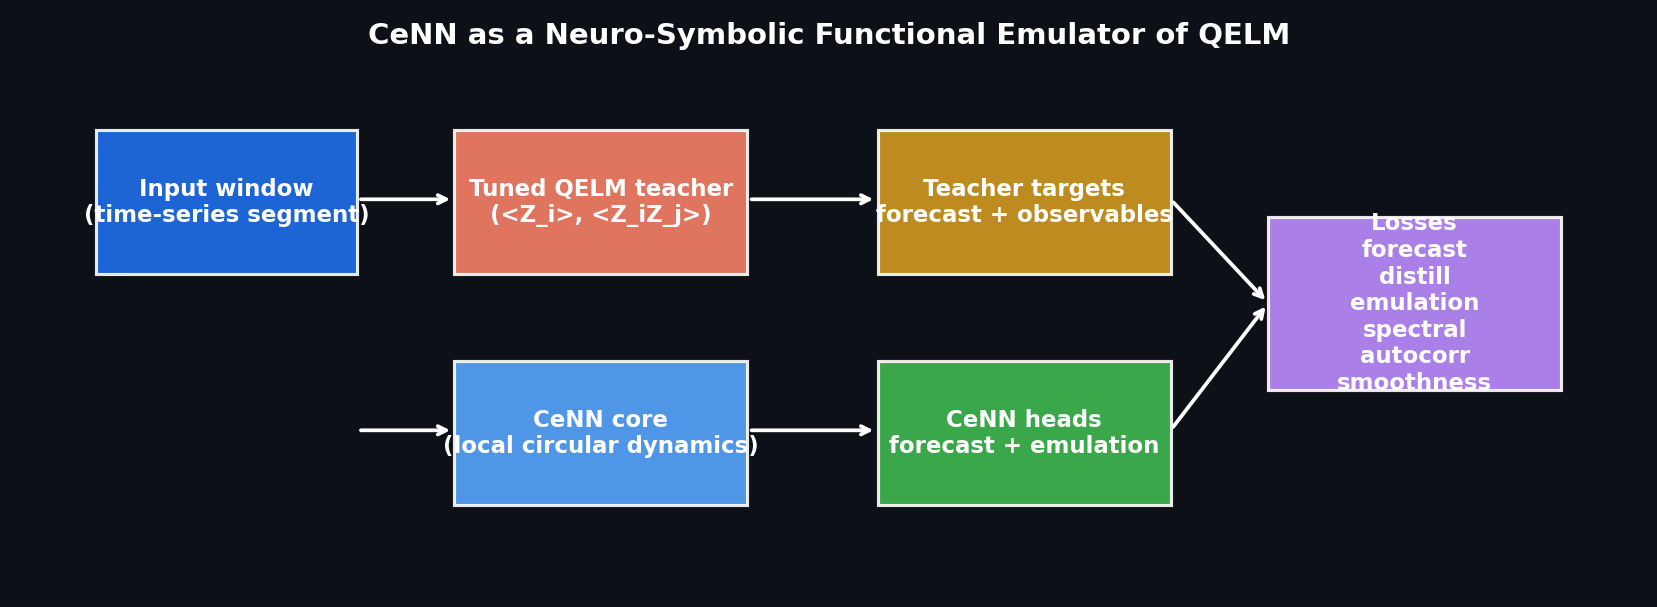

### `main_results.png`

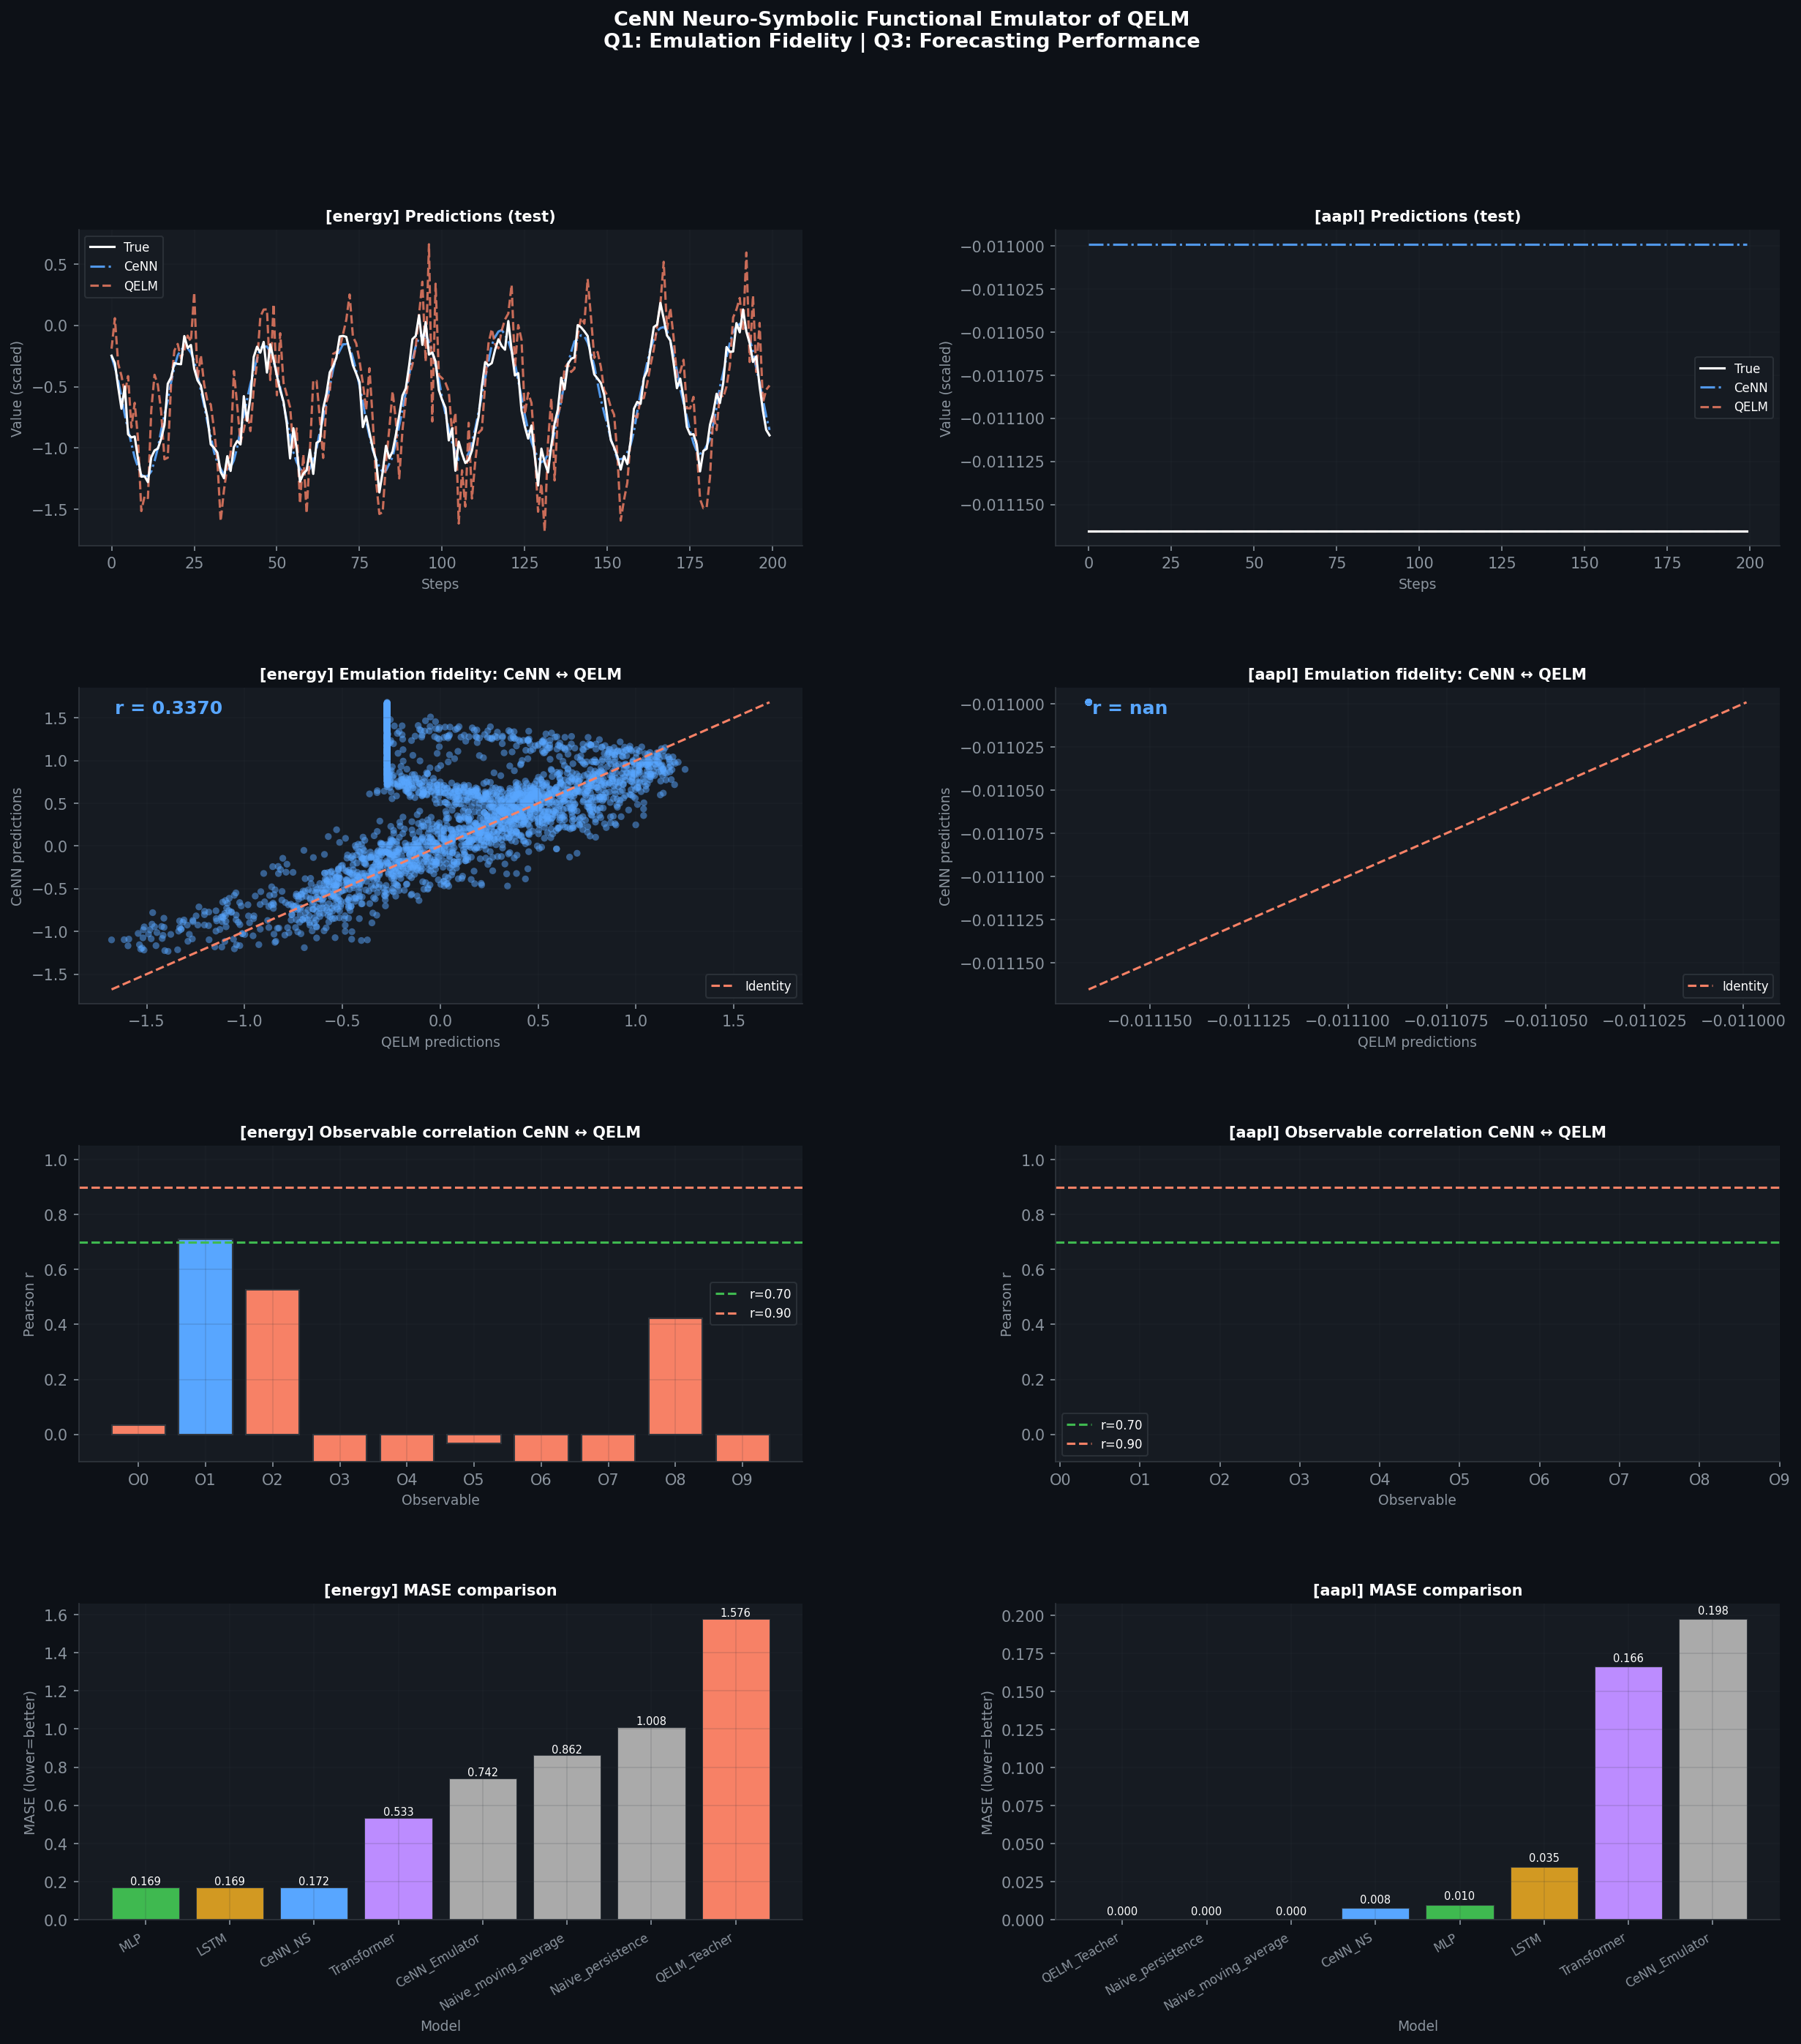

### `benchmark_mase_heatmap.png`

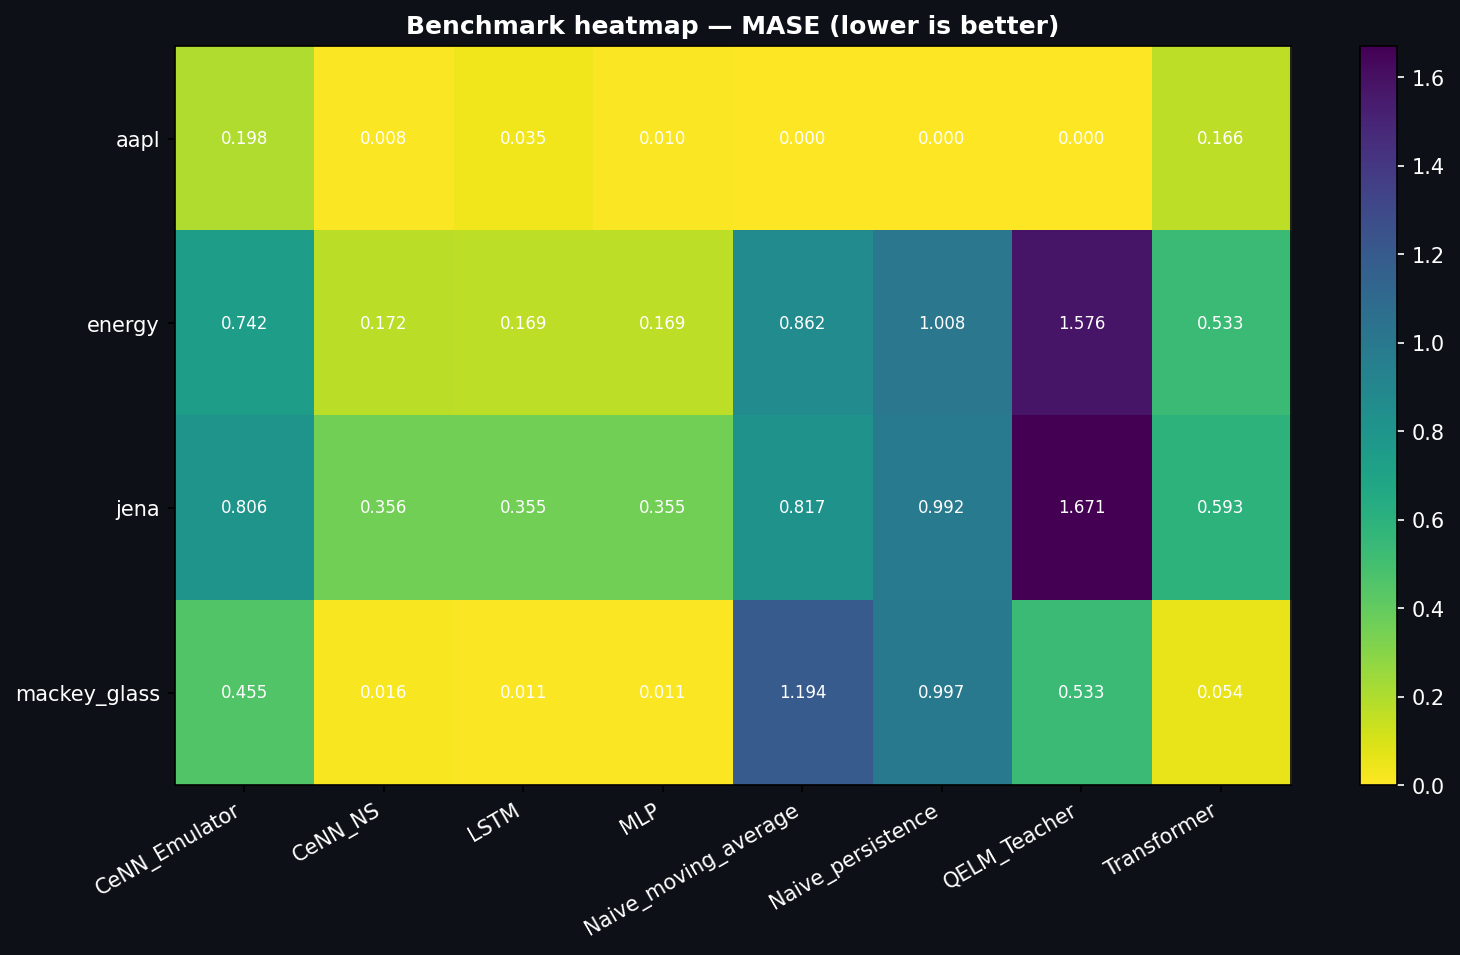

### `teacher_selection.png`

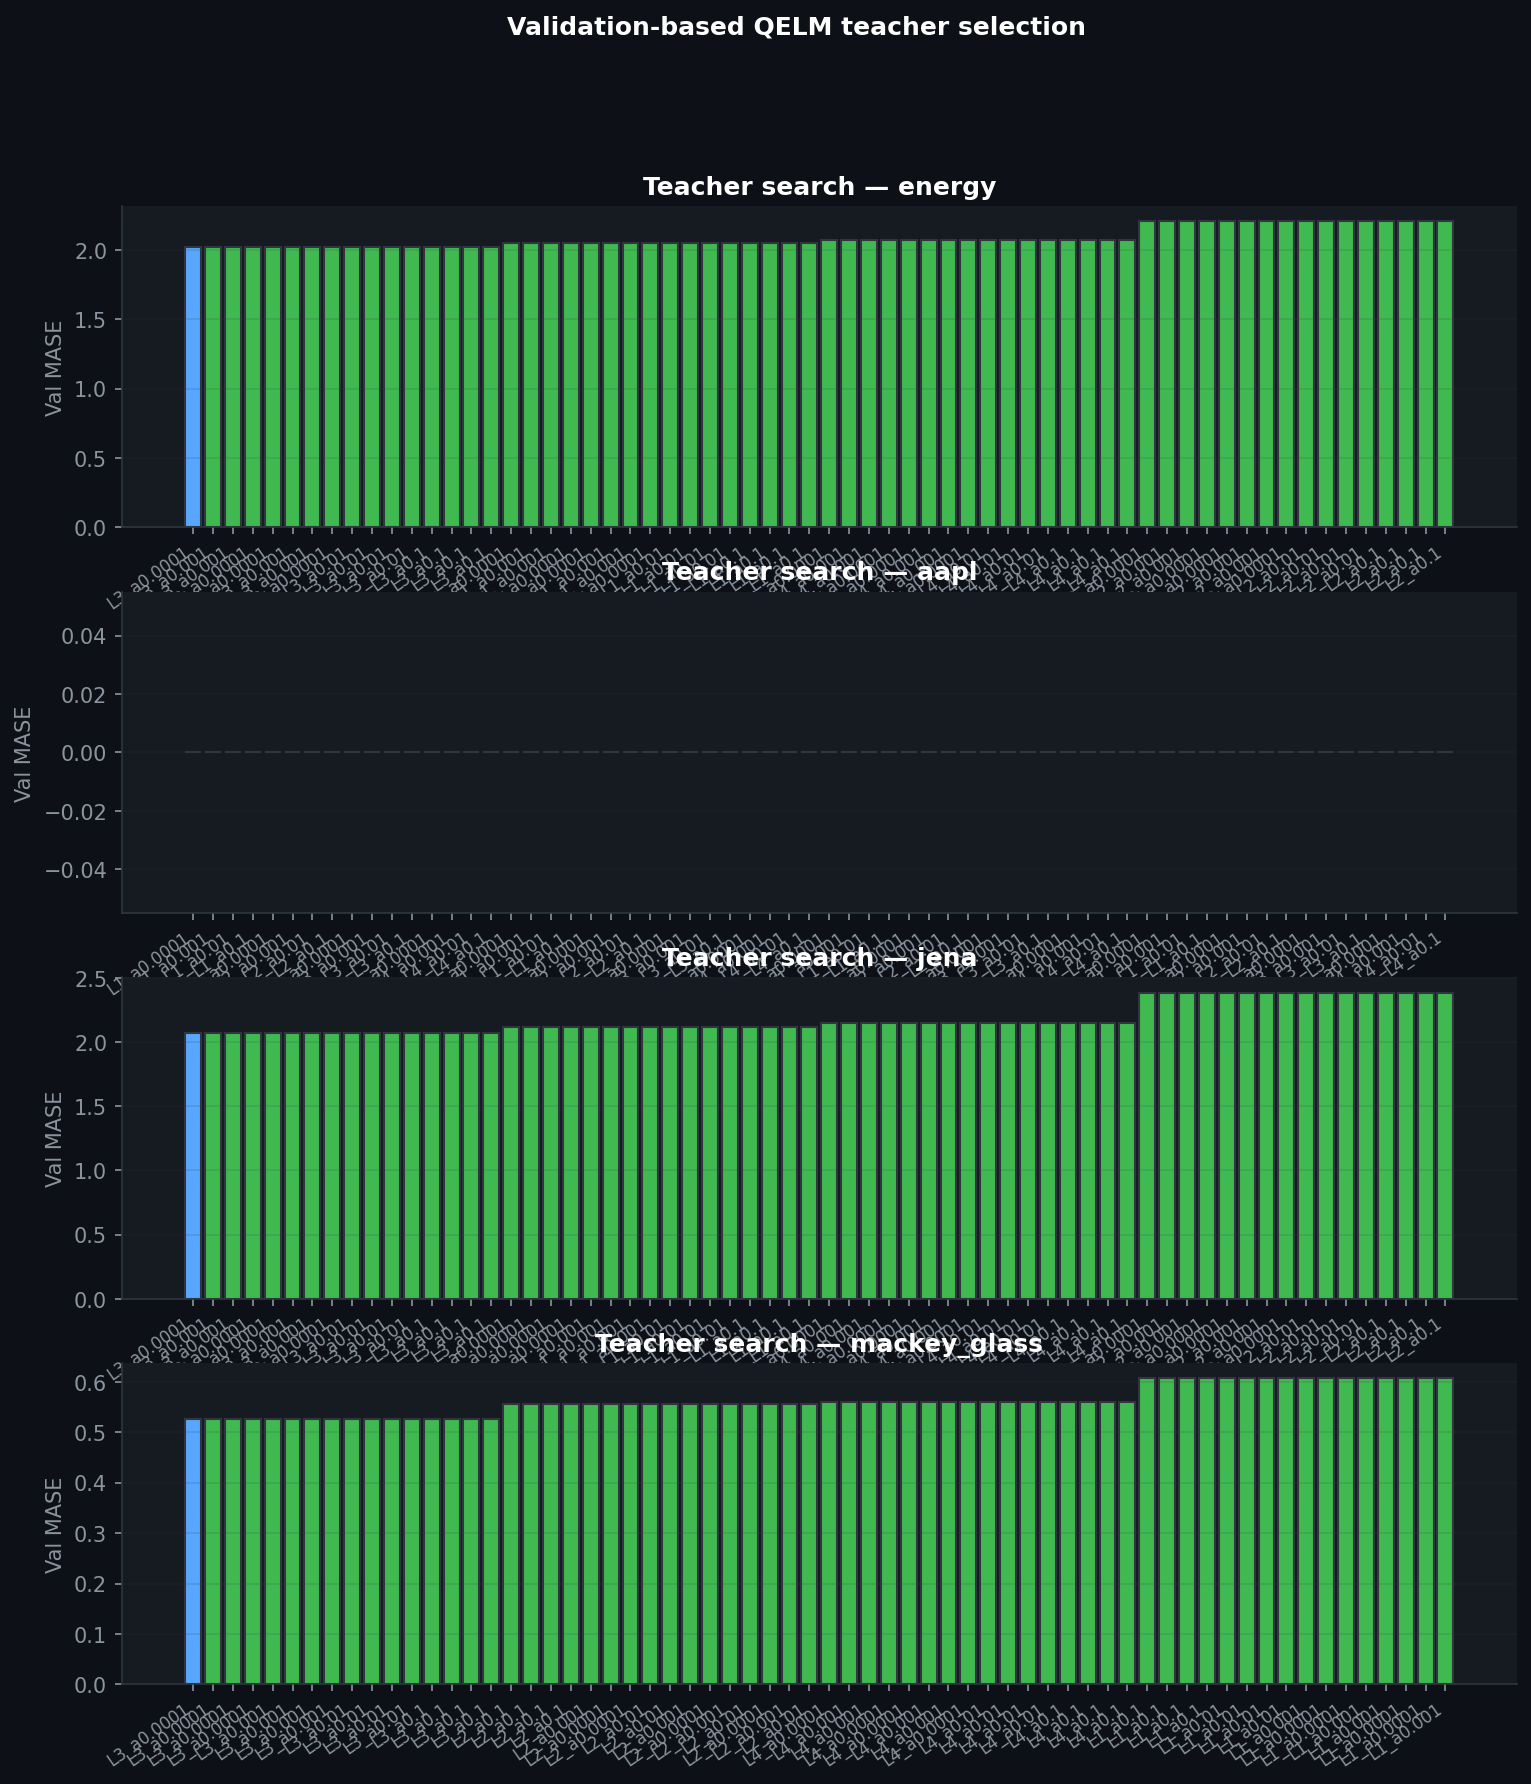

### `ablation_overview.png`

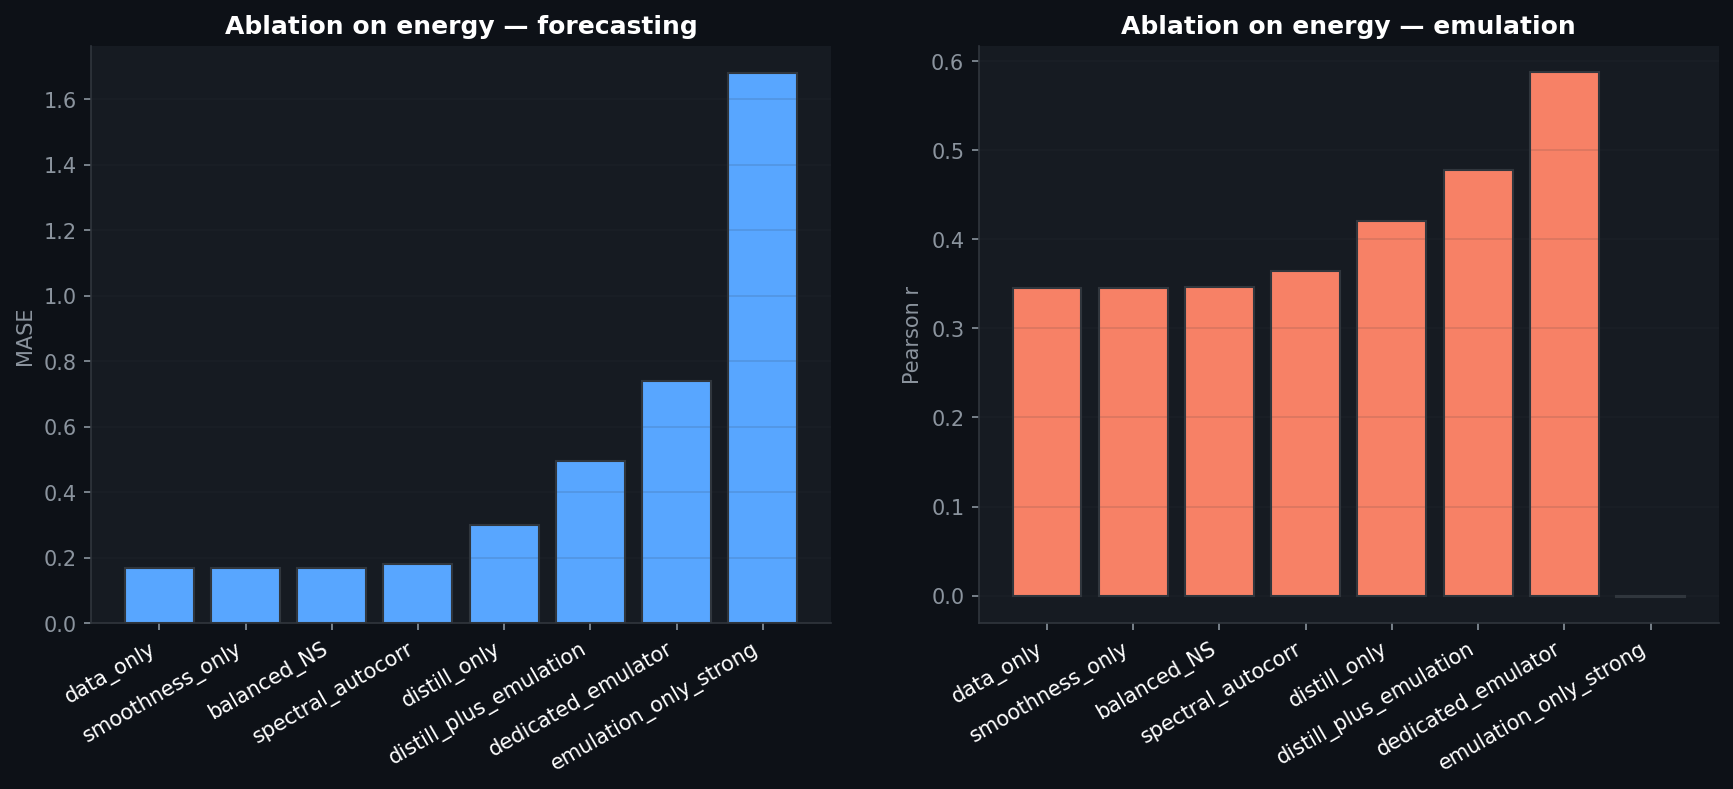

### `emulation_model_comparison.png`

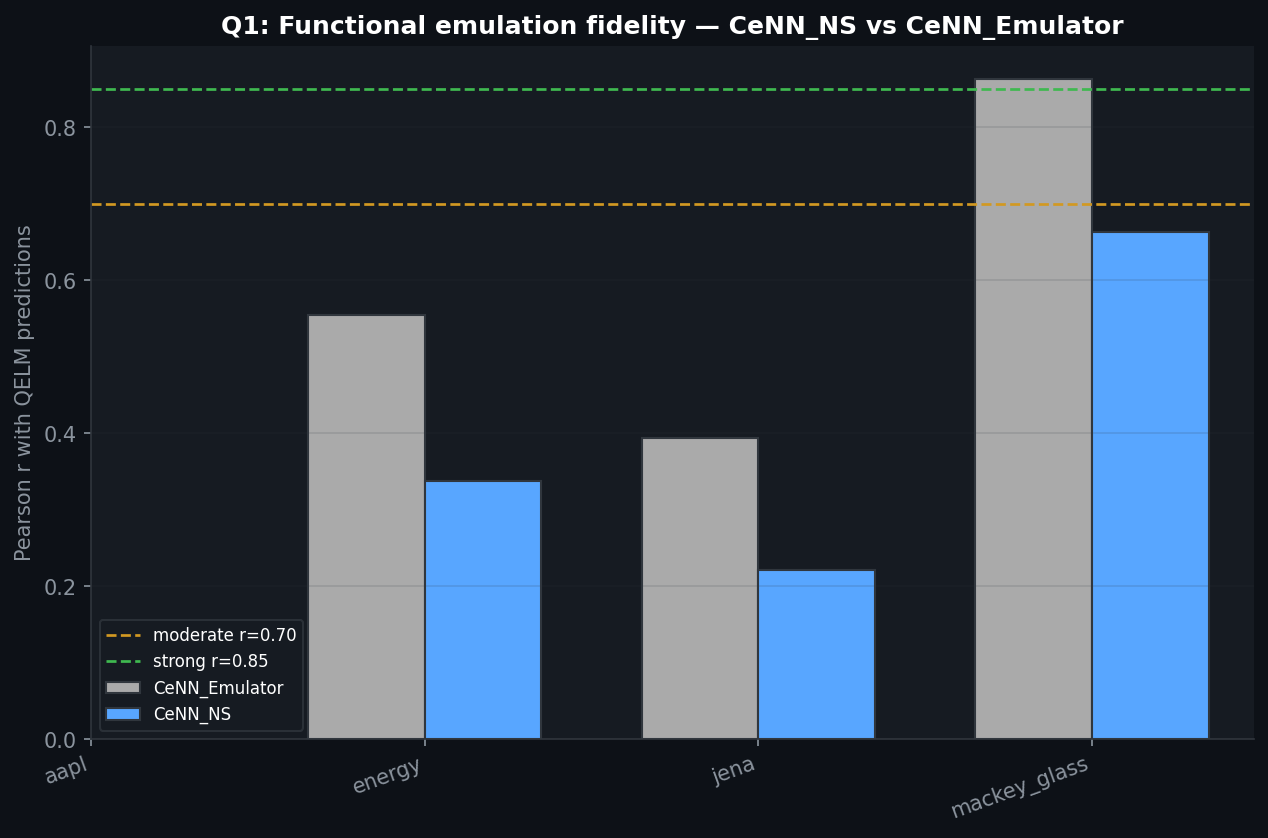

### `scalability.png`

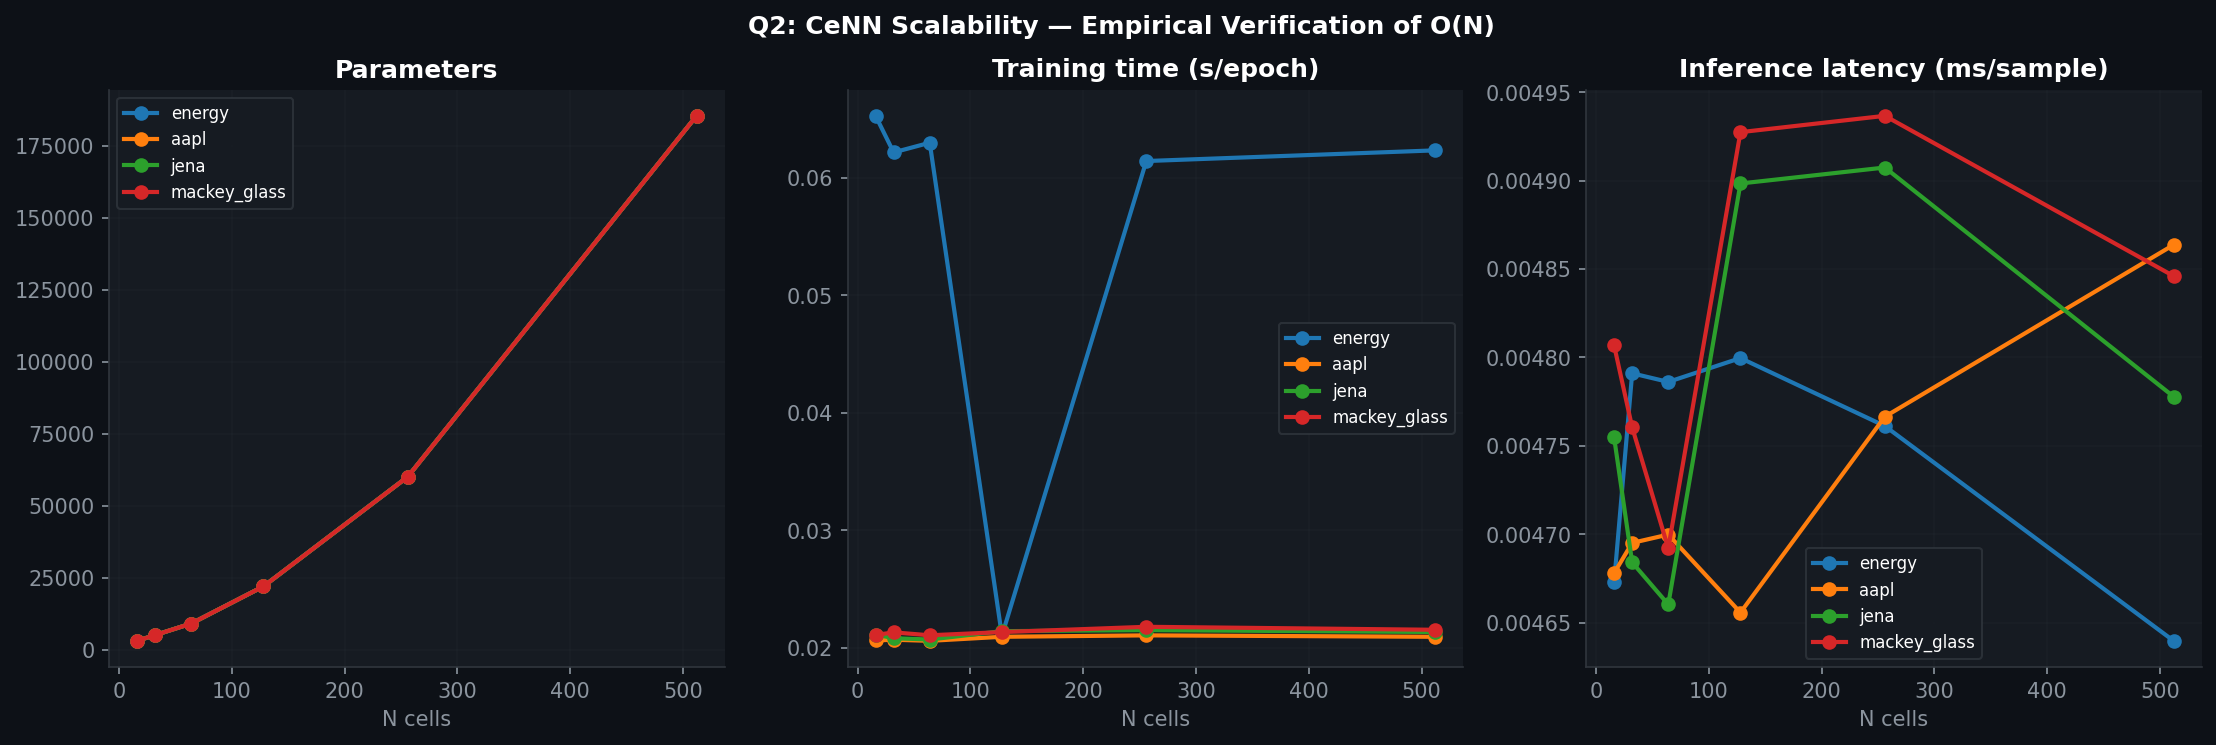

Displayed 7 GitHub-ready image(s).


In [20]:

# ================================================================
# CELL 19 — Display exported PNG assets
# ================================================================

candidate_files = [
    f'{OUTPUT_DIR}/architecture_overview.png',
    f'{OUTPUT_DIR}/main_results.png',
    f'{OUTPUT_DIR}/benchmark_mase_heatmap.png',
    f'{OUTPUT_DIR}/teacher_selection.png',
    f'{OUTPUT_DIR}/ablation_overview.png',
    f'{OUTPUT_DIR}/emulation_model_comparison.png',
    f'{OUTPUT_DIR}/scalability.png',
]

shown = 0
for p in candidate_files:
    if Path(p).exists():
        display(Markdown(f'### `{Path(p).name}`'))
        display(Image(filename=p, width=1100))
        shown += 1

if shown == 0:
    print('No PNG figure found yet. Run the previous cells first.')
else:
    print(f'Displayed {shown} GitHub-ready image(s).')



## Final note

This notebook is now structured not only as an experimental pipeline, but also as a **reusable research artifact**:

- it exports **tabular results**,
- it exports **publication/GitHub-ready figures**,
- it makes the **teacher-selection process explicit**,
- and it clarifies the distinction between **forecasting performance** and **functional QELM emulation**.

For publication-quality conclusions, always rely on **`RUN_MODE = 'full'`**.


**v11 note:** the final version adds enriched QELM observables and teacher quality control. If the smoke run completes, this is the version to switch to `RUN_MODE = 'full'`.